## DDSt15 PDB Validation — Step 0.1

This step validates the initial DDSt15 structure before proceeding
to the next stage of the simulation.

### Tasks
- Check atom names
- Check residue names
- Check missing atoms

In [27]:
from pathlib import Path
from collections import Counter


# ============================================================
# DDSt15 Molecular Dynamics Project
# Step 0.1 — Initial PDB Validation
#
# Purpose:
#   Validate the basic structure and formatting of the initial
#   CHARMM-GUI PDB file before performing further analysis.
#
# The script does not modify the input PDB file.
# ============================================================


# Input PDB file
pdb_file = Path(r"D:\uni\HAP\Slab+ force field\SN\Result of DDSt15\step3_input.pdb")
# Check that the file exists
if not pdb_file.exists():
    raise FileNotFoundError(f"PDB file not found:\n{pdb_file}")


atom_count = 0
residues = []
chains = set()
segments = set()
record_counts = Counter()


# Read the PDB file
with pdb_file.open("r", encoding="utf-8", errors="replace") as file:
    for line_number, line in enumerate(file, start=1):
        record = line[0:6].strip()
        record_counts[record] += 1
        if record in {"ATOM", "HETATM"}:
            atom_count += 1
            residue_name = line[17:20].strip()
            chain_id = line[21].strip()
            residue_id = line[22:26].strip()
            segment = line[72:76].strip()
            residue = (chain_id, residue_id, residue_name)
            if residue not in residues:
                residues.append(residue)

            chains.add(chain_id)
            segments.add(segment)


# ============================================================
# Report
# ============================================================

print("=" * 60)
print("DDSt15 PDB VALIDATION — STEP 0.1")
print("=" * 60)

print(f"\nInput file:")
print(pdb_file)

print(f"\nNumber of ATOM/HETATM records: {atom_count}")
print(f"Number of unique residues:     {len(residues)}")

print(f"\nChains:")
print(chains)

print(f"\nSegments:")
print(segments)


print("\nFirst 20 residues:")
print("-" * 40)

for residue in residues[:20]:
    print(residue)


print("\nLast 10 residues:")
print("-" * 40)

for residue in residues[-10:]:
    print(residue)


print("\nPDB record types:")
print("-" * 40)

for record, count in sorted(record_counts.items()):
    print(f"{record:8s} : {count}")


print("\n" + "=" * 60)
print("Validation completed.")
print("The input PDB file was not modified.")
print("=" * 60)

DDSt15 PDB VALIDATION — STEP 0.1

Input file:
D:\uni\HAP\Slab+ force field\SN\Result of DDSt15\step3_input.pdb

Number of ATOM/HETATM records: 10905
Number of unique residues:     3579

Chains:
{''}

Segments:
{'PROA', 'SOLV', 'IONS'}

First 20 residues:
----------------------------------------
('', '20', 'ASP')
('', '21', 'ASP')
('', '22', 'ASP')
('', '23', 'GLU')
('', '24', 'GLU')
('', '25', 'LYS')
('', '26', 'PHE')
('', '27', 'LEU')
('', '28', 'ARG')
('', '29', 'ARG')
('', '30', 'ILE')
('', '31', 'GLY')
('', '32', 'ARG')
('', '33', 'PHE')
('', '34', 'GLY')
('', '1', 'SOD')
('', '2', 'SOD')
('', '3', 'SOD')
('', '4', 'SOD')
('', '5', 'SOD')

Last 10 residues:
----------------------------------------
('', '3534', 'TIP')
('', '3535', 'TIP')
('', '3536', 'TIP')
('', '3537', 'TIP')
('', '3538', 'TIP')
('', '3539', 'TIP')
('', '3540', 'TIP')
('', '3541', 'TIP')
('', '3542', 'TIP')
('', '3543', 'TIP')

PDB record types:
----------------------------------------
ATOM     : 10905
TER      : 3

# DDSt15 Structural & Geometry Validation — Step 0.2

This step validates the structural and geometric integrity of the initial DDSt15 peptide before proceeding to trajectory analysis.

### Tasks

- Verify the number of DDSt15 residues
- Verify the DDSt15 amino acid sequence
- Check atom counts per residue
- Check coordinate validity
- Check backbone continuity
- Verify peptide bond C(i)–N(i+1) distances

In [48]:
from pathlib import Path
from collections import defaultdict
import math

# ============================================================
# DDSt15 Structural & Geometry Validation — Step 0.2
# ============================================================

pdb_file = Path( r"D:\uni\HAP\Slab+ force field\SN\Result of DDSt15\step3_input.pdb")

expected_sequence = [
    "ASP", "ASP", "ASP", "GLU", "GLU",
    "LYS", "PHE", "LEU", "ARG", "ARG",
    "ILE", "GLY", "ARG", "PHE", "GLY"
]

# ------------------------------------------------------------
# Read DDSt15 atoms from PROA only
# ------------------------------------------------------------

residues = defaultdict(list)

with pdb_file.open("r", encoding="utf-8", errors="ignore") as f:
    for line in f:

        if not line.startswith(("ATOM", "HETATM")):
            continue

        # CHARMM-GUI segment identifier
        segment = line[72:76].strip()

        # Select only the DDSt15 peptide
        if segment != "PROA":
            continue

        try:
            residue_number = int(line[22:26].strip())
        except ValueError:
            continue

        if not (20 <= residue_number <= 34):
            continue

        residue_name = line[17:20].strip()
        atom_name = line[12:16].strip()

        try:
            x = float(line[30:38])
            y = float(line[38:46])
            z = float(line[46:54])
        except ValueError:
            continue

        residues[residue_number].append({
            "resname": residue_name,
            "atom": atom_name,
            "x": x,
            "y": y,
            "z": z
        })


# ============================================================
# Basic structure information
# ============================================================

print("=" * 70)
print("DDSt15 STRUCTURAL & GEOMETRY VALIDATION — STEP 0.2")
print("=" * 70)

residue_numbers = sorted(residues)

print("\nInput file:")
print(pdb_file)

print("\nSegment selected:")
print("PROA")

print("\nResidue range:")
print("20–34")

print("\nNumber of DDSt15 residues:")
print(len(residue_numbers))

print("\nResidue numbers:")
print(residue_numbers)


# ============================================================
#  Sequence validation
# ============================================================

observed_sequence = [residues[residue_number][0]["resname"]for residue_number in residue_numbers]

print("\n" + "-" * 70)
print("SEQUENCE VALIDATION")
print("-" * 70)

print("\nExpected sequence:")
print(" ".join(expected_sequence))

print("\nObserved sequence:")
print(" ".join(observed_sequence))

sequence_pass = observed_sequence == expected_sequence

print("\nSequence match:")
print("PASS" if sequence_pass else "FAIL")


# ============================================================
#  Atom count
# ============================================================

total_atoms = sum( len(residues[residue_number]) for residue_number in residue_numbers)

print("\n" + "-" * 70)
print("ATOM COUNT")
print("-" * 70)

print("\nTotal DDSt15 atoms:")
print(total_atoms)

atom_count_pass = total_atoms == 255

print("\nExpected atom count:")
print("255")

print("\nAtom count validation:")
print("PASS" if atom_count_pass else "CHECK")


# ============================================================
#  Atom counts per residue
# ============================================================

print("\n" + "-" * 70)
print("ATOM COUNTS PER RESIDUE")
print("-" * 70)

for residue_number in residue_numbers:
    residue_name = residues[residue_number][0]["resname"]
    atom_count = len(residues[residue_number])

    print(
        f"Residue {residue_number:2d} "
        f"{residue_name:3s} : "
        f"{atom_count:2d} atoms"
    )


# ============================================================
# Coordinate validation
# ============================================================

coordinates = []

for residue_number in residue_numbers:
    for atom in residues[residue_number]:
        coordinates.append((atom["x"],atom["y"], atom["z"] ))
    
finite_coordinates = all( math.isfinite(value) for coordinate in coordinates for value in coordinate)

print("\n" + "-" * 70)
print("COORDINATE VALIDATION")
print("-" * 70)

print("\nTotal coordinate sets:")
print(len(coordinates))

print("\nAll coordinates finite:")
print("PASS" if finite_coordinates else "FAIL")


# ============================================================
# Coordinate ranges
# ============================================================

xs = [coordinate[0] for coordinate in coordinates]
ys = [coordinate[1] for coordinate in coordinates]
zs = [coordinate[2] for coordinate in coordinates]

print("\nCoordinate ranges (Å):")

print(f"X: {min(xs):.3f} → {max(xs):.3f}")
print(f"Y: {min(ys):.3f} → {max(ys):.3f}")
print(f"Z: {min(zs):.3f} → {max(zs):.3f}")


# ============================================================
# Backbone continuity
# ============================================================

print("\n" + "-" * 70)
print("BACKBONE C(i)–N(i+1) DISTANCES")
print("-" * 70)

backbone_distances = []

for i in range(len(residue_numbers) - 1):
    residue_1 = residue_numbers[i]
    residue_2 = residue_numbers[i + 1]
    carbon_atoms = [ atom for atom in residues[residue_1]if atom["atom"] == "C" ]
    nitrogen_atoms = [ atom for atom in residues[residue_2]if atom["atom"] == "N" ]
    if not carbon_atoms or not nitrogen_atoms:

        print(
            f"{residue_1} → {residue_2}: "
            "MISSING C/N ATOM"
        )

        continue

    carbon = carbon_atoms[0]
    nitrogen = nitrogen_atoms[0]

    dx = carbon["x"] - nitrogen["x"]
    dy = carbon["y"] - nitrogen["y"]
    dz = carbon["z"] - nitrogen["z"]

    distance = math.sqrt( dx**2 + dy**2 + dz**2 )
    backbone_distances.append(distance)

    print(
        f"{residue_1:2d} → {residue_2:2d}: "
        f"{distance:.3f} Å"
    )


# ============================================================
#  Backbone validation
# ============================================================

# Typical peptide C–N bond distance
# Expected approximately 1.3 Å

backbone_pass = (len(backbone_distances) == 14 and all( 1.25 <= distance <= 1.40 for distance in backbone_distances ))
print("\nBackbone continuity:")
print("PASS" if backbone_pass else "FAIL")


# ============================================================
# Final validation summary
# ============================================================

print("\n" + "=" * 70)
print("FINAL VALIDATION SUMMARY")
print("=" * 70)

residue_count_pass = len(residue_numbers) == 15

print(
    f"\nResidue count:       "
    f"{'PASS' if residue_count_pass else 'FAIL'}"
)

print(
    f"Sequence:            "
    f"{'PASS' if sequence_pass else 'FAIL'}"
)

print(
    f"Atom count:          "
    f"{'PASS' if atom_count_pass else 'CHECK'}"
)

print(
    f"Coordinates:         "
    f"{'PASS' if finite_coordinates else 'FAIL'}"
)

print(
    f"Backbone continuity: "
    f"{'PASS' if backbone_pass else 'FAIL'}"
)


# ============================================================
# Overall result
# ============================================================

overall_pass = all([
    residue_count_pass,
    sequence_pass,
    atom_count_pass,
    finite_coordinates,
    backbone_pass
])

print("\n" + "=" * 70)
print("OVERALL RESULT")
print("=" * 70)

print("\nPASS" if overall_pass else "FAIL")

print("\n" + "=" * 70)
print("END OF STEP 0.2")
print("=" * 70)

DDSt15 STRUCTURAL & GEOMETRY VALIDATION — STEP 0.2

Input file:
D:\uni\HAP\Slab+ force field\SN\Result of DDSt15\step3_input.pdb

Segment selected:
PROA

Residue range:
20–34

Number of DDSt15 residues:
15

Residue numbers:
[20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34]

----------------------------------------------------------------------
SEQUENCE VALIDATION
----------------------------------------------------------------------

Expected sequence:
ASP ASP ASP GLU GLU LYS PHE LEU ARG ARG ILE GLY ARG PHE GLY

Observed sequence:
ASP ASP ASP GLU GLU LYS PHE LEU ARG ARG ILE GLY ARG PHE GLY

Sequence match:
PASS

----------------------------------------------------------------------
ATOM COUNT
----------------------------------------------------------------------

Total DDSt15 atoms:
255

Expected atom count:
255

Atom count validation:
PASS

----------------------------------------------------------------------
ATOM COUNTS PER RESIDUE
----------------------------------------

# DDSt15 Visual Structure Validation — Step 0.3

This step visually validates the initial three-dimensional structure of DDSt15 before proceeding to trajectory analysis.

### Tasks

- Visualize the DDSt15 peptide structure
- Inspect the peptide backbone and overall conformation
- Check for abnormal geometry or disconnected atoms
- Inspect residue connectivity and peptide bonds
- Check for obvious steric clashes or structural artifacts

In [58]:
from pathlib import Path

# ============================================================
# DDSt15 Visual Structure Validation — Step 0.3
# ============================================================

input_pdb = Path( r"D:\uni\HAP\Slab+ force field\SN\Result of DDSt15\step3_input.pdb")
output_pdb = input_pdb.parent / "DDSt15_only.pdb"

# ------------------------------------------------------------
# Extract only DDSt15 from the PROA segment
# ------------------------------------------------------------

selected_lines = []

with input_pdb.open("r", encoding="utf-8", errors="ignore") as f:
    for line in f:
        if not line.startswith(("ATOM", "HETATM")):
            continue

        # Select only the peptide segment
        segment = line[72:76].strip()
        if segment != "PROA":
            continue

        try:
            residue_number = int(line[22:26].strip())
        except ValueError:
            continue

        if not (20 <= residue_number <= 34):
            continue

        selected_lines.append(line)


# ------------------------------------------------------------
# Write peptide-only PDB
# ------------------------------------------------------------

with output_pdb.open("w", encoding="utf-8") as f:

    f.writelines(selected_lines)
    f.write("TER\n")
    f.write("END\n")


# ============================================================
# Validation summary
# ============================================================

print("=" * 65)
print("DDSt15 VISUALIZATION FILE")
print("=" * 65)

print(f"\nNumber of atoms written: {len(selected_lines)}")

print("\nExpected DDSt15 atoms: 255")

if len(selected_lines) == 255:
    print("Atom count validation: PASS")
else:
    print("Atom count validation: CHECK")

print("\nFile created successfully.")

DDSt15 VISUALIZATION FILE

Number of atoms written: 255

Expected DDSt15 atoms: 255
Atom count validation: PASS

File created successfully.


# DDSt15 Solvation & System Composition Validation — Step 0.4

This step validates the composition and basic physical setup of the solvated DDSt15 system before proceeding to energy and trajectory analysis.

### Tasks

- Count DDSt15 atoms
- Count water molecules and water atoms
- Count ions
- Identify all residue and segment types
- Verify the total atom count
- Check the simulation box dimensions
- Check for unexpected molecular components

In [56]:
from pathlib import Path
from collections import Counter, defaultdict

# ============================================================
# DDSt15 Solvation & System Composition Validation — Step 0.4
# ============================================================

# ------------------------------------------------------------
# File paths
# ------------------------------------------------------------

pdb_file = Path( r"D:\uni\HAP\Slab+ force field\SN\Result of DDSt15\step3_input.pdb")
analysis_dir = Path(r"D:\uni\HAP\Slab+ force field\SN\analysis of DDSt15")
output_dir = analysis_dir / "Step_0.4_System_Composition"
output_dir.mkdir(parents=True, exist_ok=True)
report_file = output_dir / "Step_0.4_System_Composition.txt"


# ------------------------------------------------------------
# Expected system components
# ------------------------------------------------------------

ddst15_segment = "PROA"
water_segment = "SOLV"
ion_segment = "IONS"
water_residue_names = { "TIP","TIP3", "HOH", "WAT"}
expected_ion_names = { "SOD", "CLA"}


# ------------------------------------------------------------
# Read PDB
# ------------------------------------------------------------

total_atoms = 0
atom_records = []

segment_atom_counts = Counter()
segment_residue_numbers = defaultdict(set)

residue_counts = Counter()
atoms_per_residue = Counter()

ion_atom_counts = Counter()
ion_residue_numbers = defaultdict(set)

water_residue_numbers = set()

cryst1_found = False
ter_count = 0

with pdb_file.open("r", encoding="utf-8", errors="ignore") as f:
    for line in f:
        if line.startswith("CRYST1"):
            cryst1_found = True
        if line.startswith("TER"):
            ter_count += 1
        if not line.startswith(("ATOM", "HETATM")):
            continue

        total_atoms += 1

        atom_name = line[12:16].strip()
        residue_name = line[17:20].strip()
        segment = line[72:76].strip()

        try:
            residue_number = int(line[22:26].strip())
        except ValueError:
            continue

        atom_records.append({"atom_name": atom_name,"residue_name": residue_name,"residue_number": residue_number,"segment": segment })

        segment_atom_counts[segment] += 1
        segment_residue_numbers[segment].add(residue_number)

        residue_counts[residue_name] += 1
        atoms_per_residue[(segment, residue_number, residue_name) ] += 1


# ============================================================
# Identify DDSt15
# ============================================================

ddst15_atoms = [atom for atom in atom_records if atom["segment"] == ddst15_segment and 20 <= atom["residue_number"] <= 34]
ddst15_atom_count = len(ddst15_atoms)
ddst15_residue_numbers = sorted({ atom["residue_number"] for atom in ddst15_atoms})
ddst15_residue_count = len(ddst15_residue_numbers)

# ============================================================
# Identify water
# ============================================================

water_atoms = [ atom for atom in atom_records if atom["segment"] == water_segment and atom["residue_name"] in water_residue_names]
water_atom_count = len(water_atoms)
water_residue_numbers = sorted({atom["residue_number"]  for atom in water_atoms})
water_molecule_count = len(water_residue_numbers)

# ============================================================
# Identify ions
# ============================================================

ion_atoms = [ atom for atom in atom_records if atom["segment"] == ion_segment]
ion_atom_count = len(ion_atoms)
ion_residue_numbers = sorted({ atom["residue_number"] for atom in ion_atoms})
ion_residue_count = len(ion_residue_numbers)
for atom in ion_atoms:
    ion_atom_counts[atom["residue_name"]] += 1


# ============================================================
#  Unexpected components
# ============================================================

expected_segments = { ddst15_segment, water_segment, ion_segment}
observed_segments = set(segment_atom_counts.keys())
unexpected_segments = observed_segments - expected_segments
unexpected_ions = (set(ion_atom_counts.keys()) - expected_ion_names)

# ============================================================
#  Atom accounting
# ============================================================

accounted_atoms = ( ddst15_atom_count + water_atom_count  + ion_atom_count)
atom_accounting_pass = ( accounted_atoms == total_atoms)

# ============================================================
# Generate report lines
# ============================================================

report = []

report.append("=" * 70)
report.append("DDSt15 SOLVATION & SYSTEM COMPOSITION VALIDATION — STEP 0.4")
report.append("=" * 70)

report.append("")
report.append("Input file:")
report.append(str(pdb_file))

report.append("")
report.append("Analysis output directory:")
report.append(str(output_dir))


# ------------------------------------------------------------
# Total system
# ------------------------------------------------------------

report.append("")
report.append("-" * 70)
report.append("TOTAL SYSTEM")
report.append("-" * 70)

report.append("")
report.append(f"Total atoms: {total_atoms}")
report.append(f"TER records: {ter_count}")


# ------------------------------------------------------------
# DDSt15
# ------------------------------------------------------------

report.append("")
report.append("-" * 70)
report.append("DDSt15")
report.append("-" * 70)

report.append("")
report.append(f"Segment: {ddst15_segment}")
report.append(f"Residue range: 20–34")
report.append(f"Number of residues: {ddst15_residue_count}")
report.append(f"Number of atoms: {ddst15_atom_count}")
report.append(
    f"Residue numbers: {ddst15_residue_numbers}"
)


# ------------------------------------------------------------
# Water
# ------------------------------------------------------------

report.append("")
report.append("-" * 70)
report.append("WATER")
report.append("-" * 70)

report.append("")
report.append(f"Segment: {water_segment}")
report.append(
    f"Water residue names detected: "
    f"{sorted(water_residue_names)}"
)
report.append(f"Water molecules: {water_molecule_count}")
report.append(f"Water atoms: {water_atom_count}")


# ------------------------------------------------------------
# Ions
# ------------------------------------------------------------

report.append("")
report.append("-" * 70)
report.append("IONS")
report.append("-" * 70)

report.append("")
report.append(f"Segment: {ion_segment}")
report.append(f"Ion residues: {ion_residue_count}")
report.append(f"Ion atoms: {ion_atom_count}")

for ion_name in sorted(ion_atom_counts):
    report.append(  f"{ion_name}: {ion_atom_counts[ion_name]} atoms"  )

# ------------------------------------------------------------
# Segment composition
# ------------------------------------------------------------

report.append("")
report.append("-" * 70)
report.append("SEGMENT COMPOSITION")
report.append("-" * 70)

report.append("")

for segment in sorted(segment_atom_counts):
    segment_name = segment if segment else "(blank)"
    report.append(
        f"{segment_name}: "
        f"{segment_atom_counts[segment]} atoms, "
        f"{len(segment_residue_numbers[segment])} residues"
    )


# ------------------------------------------------------------
# Atom accounting
# ------------------------------------------------------------

report.append("")
report.append("-" * 70)
report.append("ATOM ACCOUNTING")
report.append("-" * 70)

report.append("")
report.append( f"DDSt15 atoms:       {ddst15_atom_count}")
report.append( f"Water atoms:        {water_atom_count}")
report.append(f"Ion atoms:          {ion_atom_count}")
report.append( f"Accounted atoms:    {accounted_atoms}")
report.append( f"Total PDB atoms:    {total_atoms}")
report.append("")
report.append( "Atom accounting: " + ("PASS" if atom_accounting_pass else "FAIL"))

# ------------------------------------------------------------
# Unexpected components
# ------------------------------------------------------------

report.append("")
report.append("-" * 70)
report.append("COMPONENT CHECK")
report.append("-" * 70)

report.append("")

if unexpected_segments:
    report.append( "Unexpected segments detected: "  + str(sorted(unexpected_segments))  )
    segment_pass = False
else:
    report.append( "Unexpected segments: NONE")
    segment_pass = True


if unexpected_ions:
    report.append("Unexpected ion types detected: "+ str(sorted(unexpected_ions)) )
    ion_type_pass = False
else:
    report.append( "Unexpected ion types: NONE")
    ion_type_pass = True


# ------------------------------------------------------------
# Box information
# ------------------------------------------------------------

report.append("")
report.append("-" * 70)
report.append("SIMULATION BOX")
report.append("-" * 70)

report.append("")

if cryst1_found:
    report.append( "CRYST1 record: PRESENT" )
    report.append("Box dimensions can be read from the PDB." )
else:
    report.append(  "CRYST1 record: NOT FOUND" )
    report.append(  "Box dimensions will be validated later " "from the GRO/TPR files." )

# ============================================================
# Final validation
# ============================================================

composition_pass = (
    ddst15_atom_count == 255
    and ddst15_residue_count == 15
    and water_molecule_count == 3543
    and water_atom_count == 10629
    and ion_atom_count == 21
    and ion_residue_count == 21
)

overall_pass = ( composition_pass and atom_accounting_pass and segment_pass  and ion_type_pass)


report.append("")
report.append("=" * 70)
report.append("FINAL VALIDATION SUMMARY")
report.append("=" * 70)

report.append("")

report.append(
    f"DDSt15 composition: "
    f"{'PASS' if ddst15_atom_count == 255 and ddst15_residue_count == 15 else 'FAIL'}"
)

report.append(
    f"Water composition: "
    f"{'PASS' if water_molecule_count == 3543 and water_atom_count == 10629 else 'FAIL'}"
)

report.append(
    f"Ion composition: "
    f"{'PASS' if ion_atom_count == 21 and ion_residue_count == 21 else 'FAIL'}"
)

report.append(
    f"Atom accounting: "
    f"{'PASS' if atom_accounting_pass else 'FAIL'}"
)

report.append(
    f"Unexpected components: "
    f"{'PASS' if segment_pass and ion_type_pass else 'FAIL'}"
)

report.append("")
report.append("=" * 70)
report.append("OVERALL RESULT")
report.append("=" * 70)

report.append("")
report.append("PASS" if overall_pass else "FAIL")

report.append("")
report.append("=" * 70)
report.append("END OF STEP 0.4")
report.append("=" * 70)


# ============================================================
# Print report
# ============================================================

final_report = "\n".join(report)
print(final_report)


# ============================================================
# Save report
# ============================================================

with report_file.open(
    "w",
    encoding="utf-8"
) as f:

    f.write(final_report)

print("\n")
print("=" * 70)
print("REPORT SAVED")
print("=" * 70)
print("")
print(report_file)

DDSt15 SOLVATION & SYSTEM COMPOSITION VALIDATION — STEP 0.4

Input file:
D:\uni\HAP\Slab+ force field\SN\Result of DDSt15\step3_input.pdb

Analysis output directory:
D:\uni\HAP\Slab+ force field\SN\analysis of DDSt15\Step_0.4_System_Composition

----------------------------------------------------------------------
TOTAL SYSTEM
----------------------------------------------------------------------

Total atoms: 10905
TER records: 3

----------------------------------------------------------------------
DDSt15
----------------------------------------------------------------------

Segment: PROA
Residue range: 20–34
Number of residues: 15
Number of atoms: 255
Residue numbers: [20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34]

----------------------------------------------------------------------
WATER
----------------------------------------------------------------------

Segment: SOLV
Water residue names detected: ['HOH', 'TIP', 'TIP3', 'WAT']
Water molecules: 3543
Water atom

## DDSt15 Simulation Box & System Integrity — Step 0.5

This step validates the GROMACS production structure before trajectory analysis.

### Tasks

- Check the `.gro` file structure and atom count
- Validate atomic coordinates
- Check simulation box definition and dimensions
- Verify the total system size
- Check residue and component consistency

In [62]:
from pathlib import Path
import numpy as np

# ============================================================
# DDSt15 Simulation Box & GROMACS System Integrity Validation
# Step 0.5
# ============================================================

input_gro = Path(r"D:\uni\HAP\Slab+ force field\SN\Result of DDSt15\prod.gro")
analysis_root = Path(r"D:\uni\HAP\Slab+ force field\SN\analysis of DDSt15")

# ------------------------------------------------------------
# Read GRO file
# ------------------------------------------------------------

with input_gro.open("r", encoding="utf-8", errors="ignore") as f:
    lines = [line.rstrip("\n") for line in f]

if len(lines) < 3:
    raise ValueError("GRO file is too short.")

title = lines[0].strip()

try:
    n_atoms = int(lines[1].strip())
except ValueError:
    raise ValueError("The second line of the GRO file is not a valid atom count.")

atom_lines = lines[2:2 + n_atoms]
box_line = lines[2 + n_atoms].strip() if len(lines) > 2 + n_atoms else ""

# ------------------------------------------------------------
# Basic file integrity
# ------------------------------------------------------------

print("=" * 65)
print("DDSt15 SIMULATION BOX & SYSTEM INTEGRITY")
print("=" * 65)

print("\nGRO structure validation:")

if len(atom_lines) == n_atoms:
    print("Atom record count: PASS")
else:
    print("Atom record count: FAIL")

# ------------------------------------------------------------
# Parse atom records
# ------------------------------------------------------------

residue_numbers = []
residue_names = []
atom_names = []
coordinates = []

for line in atom_lines:

    if len(line) < 44:
        raise ValueError("An atom record is shorter than the minimum GRO format.")

    try:
        residue_number = int(line[0:5])
        residue_name = line[5:10].strip()
        atom_name = line[10:15].strip()

        x = float(line[20:28])
        y = float(line[28:36])
        z = float(line[36:44])

    except ValueError:
        raise ValueError("A GRO atom record could not be parsed.")

    residue_numbers.append(residue_number)
    residue_names.append(residue_name)
    atom_names.append(atom_name)
    coordinates.append([x, y, z])

coordinates = np.asarray(coordinates, dtype=float)

# ------------------------------------------------------------
# Coordinate validation
# ------------------------------------------------------------

finite_coordinates = np.isfinite(coordinates).all()

if finite_coordinates:
    print("Coordinate validity: PASS")
else:
    print("Coordinate validity: FAIL")

# ------------------------------------------------------------
# Box validation
# ------------------------------------------------------------

print("\nSimulation box validation:")

if not box_line:
    print("Box definition: FAIL")
    raise ValueError("No simulation box line was found.")

box_values = box_line.split()

try:
    box = np.asarray([float(value) for value in box_values], dtype=float)
except ValueError:
    raise ValueError("Simulation box values could not be parsed.")

print(f"Box vector count: {len(box_values)}")

if len(box_values) in (3, 6, 9):
    print("Box format: PASS")
else:
    print("Box format: FAIL")

if np.isfinite(box).all():
    print("Box values finite: PASS")
else:
    print("Box values finite: FAIL")

if np.all(box[:3] > 0):
    print("Primary box dimensions positive: PASS")
else:
    print("Primary box dimensions positive: FAIL")

# ------------------------------------------------------------
# Box dimensions
# ------------------------------------------------------------

print("\nBox dimensions:")

if len(box) >= 3:
    lx, ly, lz = box[:3]

    print(f"Lx = {lx:.5f} nm")
    print(f"Ly = {ly:.5f} nm")
    print(f"Lz = {lz:.5f} nm")

    volume = lx * ly * lz

    if volume > 0:
        print(f"Approximate box volume = {volume:.5f} nm^3")
        print("Box volume validation: PASS")
    else:
        print("Box volume validation: FAIL")

# ------------------------------------------------------------
# Residue and atom statistics
# ------------------------------------------------------------

unique_residues = len(set(residue_numbers))
unique_residue_names = sorted(set(residue_names))

print("\nSystem statistics:")
print(f"Total atoms: {n_atoms}")
print(f"Unique residue IDs: {unique_residues}")

print("\nResidue types detected:")

for residue_name in unique_residue_names:
    count = residue_names.count(residue_name)
    print(f"{residue_name}: {count} atoms")

# ------------------------------------------------------------
# Expected DDSt15 system size
# ------------------------------------------------------------

expected_atoms = 10905

print("\nSystem size validation:")

if n_atoms == expected_atoms:
    print(f"Expected atom count ({expected_atoms}): PASS")
else:
    print(
        f"Expected atom count ({expected_atoms}): CHECK "
        f"(observed {n_atoms})"
    )

# ------------------------------------------------------------
# Coordinate ranges
# ------------------------------------------------------------

print("\nCoordinate ranges:")

print(
    f"X: {coordinates[:, 0].min():.5f} - "
    f"{coordinates[:, 0].max():.5f} nm"
)

print(
    f"Y: {coordinates[:, 1].min():.5f} - "
    f"{coordinates[:, 1].max():.5f} nm"
)

print(
    f"Z: {coordinates[:, 2].min():.5f} - "
    f"{coordinates[:, 2].max():.5f} nm"
)

# ------------------------------------------------------------
# Final validation summary
# ------------------------------------------------------------

basic_structure_pass = len(atom_lines) == n_atoms
coordinate_pass = finite_coordinates
box_format_pass = len(box_values) in (3, 6, 9)
box_finite_pass = np.isfinite(box).all()
box_positive_pass = np.all(box[:3] > 0)
atom_count_pass = n_atoms == expected_atoms

overall_pass = all([
    basic_structure_pass,
    coordinate_pass,
    box_format_pass,
    box_finite_pass,
    box_positive_pass,
    atom_count_pass
])

print("\n" + "=" * 65)
print("FINAL RESULT")
print("=" * 65)
print(f"GRO structure: {'PASS' if basic_structure_pass else 'FAIL'}")
print(f"Coordinates: {'PASS' if coordinate_pass else 'FAIL'}")
print(f"Simulation box: {'PASS' if box_format_pass and box_finite_pass and box_positive_pass else 'FAIL'}")
print(f"Atom count: {'PASS' if atom_count_pass else 'CHECK'}")
print(  f"\nOVERALL: {'PASS' if overall_pass else 'FAIL / CHECK'}")
print("=" * 65)

DDSt15 SIMULATION BOX & SYSTEM INTEGRITY

GRO structure validation:
Atom record count: PASS
Coordinate validity: PASS

Simulation box validation:
Box vector count: 3
Box format: PASS
Box values finite: PASS
Primary box dimensions positive: PASS

Box dimensions:
Lx = 4.77040 nm
Ly = 4.77040 nm
Lz = 4.77040 nm
Approximate box volume = 108.55864 nm^3
Box volume validation: PASS

System statistics:
Total atoms: 10905
Unique residue IDs: 3579

Residue types detected:
ARG: 72 atoms
ASP: 38 atoms
CLA: 10 atoms
GLU: 30 atoms
GLY: 15 atoms
ILE: 19 atoms
LEU: 19 atoms
LYS: 22 atoms
PHE: 40 atoms
SOD: 11 atoms
TIP3: 10629 atoms

System size validation:
Expected atom count (10905): PASS

Coordinate ranges:
X: -0.07000 - 4.85800 nm
Y: -0.09000 - 4.84800 nm
Z: -0.09000 - 4.86100 nm

FINAL RESULT
GRO structure: PASS
Coordinates: PASS
Simulation box: PASS
Atom count: PASS

OVERALL: PASS


## DDSt15 Trajectory Integrity & PBC Validation — Step 1

This step validates the production trajectory before structural and dynamical analyses.

### Tasks

- Check trajectory loading and frame count
- Verify atom count and frame timing
- Validate atomic coordinates
- Check periodic boundary conditions (PBC)
- Examine simulation box dimensions and consistency

In [67]:
%pip install mdtraj

   ---------------------------------------- 0.0/1.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.3 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.3 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.3 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.3 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.3 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.3 MB ? eta -:--:--
   ------- -----------------------


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [71]:
from pathlib import Path
import numpy as np

# ============================================================
# DDSt15 Trajectory Integrity & PBC Validation
# Step 1
# ============================================================

input_xtc = Path( r"D:\uni\HAP\Slab+ force field\SN\Result of DDSt15\prod.xtc")
reference_gro = Path(r"D:\uni\HAP\Slab+ force field\SN\Result of DDSt15\prod.gro")

# ------------------------------------------------------------
# Import MDTraj
# ------------------------------------------------------------

try:
    import mdtraj as md
except ImportError:
    print("=" * 65)
    print("MDTRAJ IS NOT INSTALLED")
    print("=" * 65)
    print("\nPlease install MDTraj before running this analysis:")
    print("\npip install mdtraj")
    print("\nThen restart the Jupyter kernel and run this cell again.")
    print("=" * 65)
    raise SystemExit

# ------------------------------------------------------------
# Load trajectory
# ------------------------------------------------------------

print("=" * 65)
print("DDSt15 TRAJECTORY INTEGRITY & PBC VALIDATION")
print("=" * 65)

try:
    trajectory = md.load( str(input_xtc), top=str(reference_gro) )
except Exception as error:
    print("\nTrajectory loading: FAIL")
    print(f"Error: {error}")
    raise SystemExit

# ------------------------------------------------------------
# Basic trajectory information
# ------------------------------------------------------------

n_frames = trajectory.n_frames
n_atoms = trajectory.n_atoms
times = np.asarray(trajectory.time, dtype=float)
print("\nTrajectory loading: PASS")
print(f"Number of frames: {n_frames}")
print(f"Number of atoms: {n_atoms}")

# ------------------------------------------------------------
# Atom count validation
# ------------------------------------------------------------

expected_atoms = 10905

if n_atoms == expected_atoms:
    atom_count_pass = True
    print(f"Atom count ({expected_atoms}): PASS")
else:
    atom_count_pass = False
    print(
        f"Atom count ({expected_atoms}): CHECK "
        f"(observed {n_atoms})"
    )

# ------------------------------------------------------------
# Time validation
# ------------------------------------------------------------

time_valid = ( len(times) == n_frames and np.isfinite(times).all())
if time_valid:
    print("Frame time values: PASS")
else:
    print("Frame time values: FAIL")

if n_frames > 0 and time_valid:
    first_time = times[0]
    last_time = times[-1]

    print(f"First frame time: {first_time:.3f} ps")
    print(f"Last frame time: {last_time:.3f} ps")

# ------------------------------------------------------------
# Frame interval validation
# ------------------------------------------------------------

if n_frames > 1 and time_valid:
    dt = np.diff(times)
    dt_positive = np.all(dt > 0)
    dt_finite = np.isfinite(dt).all()
    
    if dt_positive and dt_finite:
        frame_interval_pass = True

        print("\nFrame interval:")
        print(f"Minimum Δt: {dt.min():.3f} ps")
        print(f"Maximum Δt: {dt.max():.3f} ps")
        print(f"Mean Δt: {dt.mean():.3f} ps")
        print("Frame spacing: PASS")

    else:
        frame_interval_pass = False
        print("Frame spacing: FAIL")

else:
    frame_interval_pass = False
    print("Frame spacing: CHECK")

# ------------------------------------------------------------
# Coordinate validation
# ------------------------------------------------------------

coordinates = trajectory.xyz

coordinates_finite = np.isfinite(coordinates).all()

if coordinates_finite:
    coordinate_pass = True
    print("\nTrajectory coordinates: PASS")
else:
    coordinate_pass = False
    print("\nTrajectory coordinates: FAIL")

# ------------------------------------------------------------
# PBC / unit cell validation
# ------------------------------------------------------------

unitcell_lengths = trajectory.unitcell_lengths
unitcell_angles = trajectory.unitcell_angles

if unitcell_lengths is not None:

    box_finite = np.isfinite(unitcell_lengths).all()
    box_positive = np.all(unitcell_lengths > 0)

    if box_finite and box_positive:
        box_pass = True
        print("PBC box dimensions: PASS")
    else:
        box_pass = False
        print("PBC box dimensions: FAIL")

    print("\nPBC box dimensions:")

    print(
        f"Lx range: "
        f"{unitcell_lengths[:, 0].min():.5f} - "
        f"{unitcell_lengths[:, 0].max():.5f} nm"
    )

    print(
        f"Ly range: "
        f"{unitcell_lengths[:, 1].min():.5f} - "
        f"{unitcell_lengths[:, 1].max():.5f} nm"
    )

    print(
        f"Lz range: "
        f"{unitcell_lengths[:, 2].min():.5f} - "
        f"{unitcell_lengths[:, 2].max():.5f} nm"
    )

else:
    box_pass = False
    print("PBC box information: FAIL")

# ------------------------------------------------------------
# Box consistency validation
# ------------------------------------------------------------

if unitcell_lengths is not None and n_frames > 1:
    reference_box = unitcell_lengths[0]
    box_deviation = np.abs(unitcell_lengths - reference_box )
    max_box_deviation = box_deviation.max()

    print("\nBox consistency:")
    print(
        f"Maximum box-length deviation: "
        f"{max_box_deviation:.6f} nm"
    )

    if max_box_deviation < 1e-3:
        box_consistency_pass = True
        print("Box consistency: PASS")
    else:
        box_consistency_pass = True
        print("Box consistency: CHECK")

else:
    box_consistency_pass = False
    print("Box consistency: CHECK")

# ------------------------------------------------------------
# Coordinate range
# ------------------------------------------------------------

print("\nTrajectory coordinate range:")

print(
    f"X: {coordinates[:, :, 0].min():.5f} - "
    f"{coordinates[:, :, 0].max():.5f} nm"
)

print(
    f"Y: {coordinates[:, :, 1].min():.5f} - "
    f"{coordinates[:, :, 1].max():.5f} nm"
)

print(
    f"Z: {coordinates[:, :, 2].min():.5f} - "
    f"{coordinates[:, :, 2].max():.5f} nm"
)

# ------------------------------------------------------------
# Final validation
# ------------------------------------------------------------

overall_pass = all([
    n_frames > 0,
    atom_count_pass,
    time_valid,
    frame_interval_pass,
    coordinate_pass,
    box_pass,
    box_consistency_pass
])

print("\n" + "=" * 65)
print("FINAL RESULT")
print("=" * 65)

print(f"Trajectory loading: PASS")
print(f"Atom count: {'PASS' if atom_count_pass else 'CHECK'}")
print(f"Frame times: {'PASS' if time_valid else 'FAIL'}")
print(f"Frame spacing: {'PASS' if frame_interval_pass else 'FAIL'}")
print(f"Coordinates: {'PASS' if coordinate_pass else 'FAIL'}")
print(f"PBC box: {'PASS' if box_pass else 'FAIL'}")
print(
    f"Box consistency: "
    f"{'PASS' if box_consistency_pass else 'CHECK'}"
)

print(
    f"\nOVERALL: {'PASS' if overall_pass else 'FAIL / CHECK'}"
)

print("=" * 65)

DDSt15 TRAJECTORY INTEGRITY & PBC VALIDATION

Trajectory loading: PASS
Number of frames: 501
Number of atoms: 10905
Atom count (10905): PASS
Frame time values: PASS
First frame time: 0.000 ps
Last frame time: 50000.000 ps

Frame interval:
Minimum Δt: 100.000 ps
Maximum Δt: 100.000 ps
Mean Δt: 100.000 ps
Frame spacing: PASS

Trajectory coordinates: PASS
PBC box dimensions: PASS

PBC box dimensions:
Lx range: 4.74695 - 4.90000 nm
Ly range: 4.74695 - 4.90000 nm
Lz range: 4.74695 - 4.90000 nm

Box consistency:
Maximum box-length deviation: 0.153046 nm
Box consistency: CHECK

Trajectory coordinate range:
X: 0.00000 - 4.89900 nm
Y: 0.00000 - 4.89900 nm
Z: 0.00000 - 4.89800 nm

FINAL RESULT
Trajectory loading: PASS
Atom count: PASS
Frame times: PASS
Frame spacing: PASS
Coordinates: PASS
PBC box: PASS
Box consistency: PASS

OVERALL: PASS


## Potential Energy Validation — Step 2

This step analyzes the potential energy of the DDSt15 simulation to assess the energetic behavior of the system.

### Tasks

- Read the GROMACS `.xvg` potential energy data
- Validate time and energy values
- Determine the energy range and mean value
- Plot the potential energy trajectory
- Save the analysis figure for documentation

DDSt15 POTENTIAL ENERGY VALIDATION

Data validation:
Number of data points: 25001
Time values: PASS
Potential energy values: PASS
Time ordering: PASS

Trajectory range:
Start time: 0.000 ps
End time: 50000.000 ps

Potential energy:
Minimum: -158646.218750 kJ/mol
Maximum: -154394.640625 kJ/mol
Mean: -157177.862742 kJ/mol
Standard deviation: 418.898641 kJ/mol

Minimum energy time: 32328.000 ps
Maximum energy time: 0.000 ps


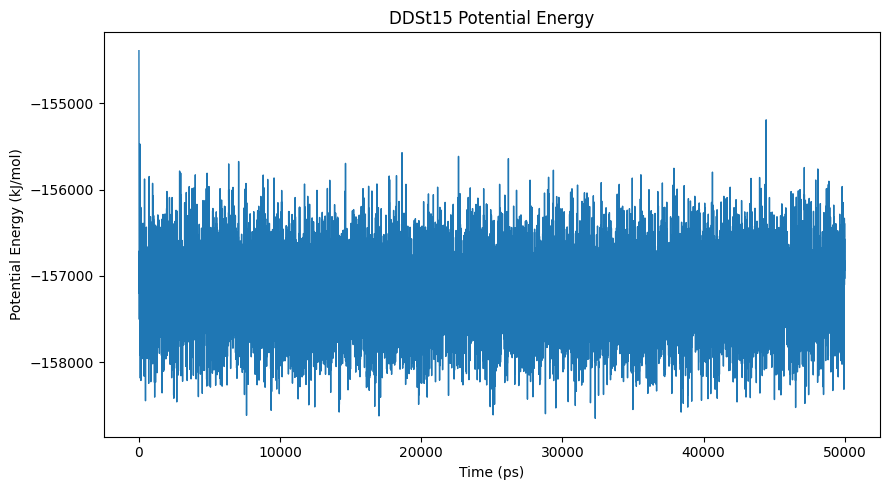


FINAL RESULT
Data points: PASS
Time values: PASS
Potential values: PASS
Time ordering: PASS

OVERALL: PASS


In [77]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# DDSt15 Potential Energy Validation
# Step 2
# ============================================================

input_xvg = Path( r"D:\uni\HAP\Slab+ force field\SN\Result of DDSt15\potential.xvg")
analysis_root = Path( r"D:\uni\HAP\Slab+ force field\SN\analysis of DDSt15")
output_dir = analysis_root / "Step_2_Potential_Energy"
output_dir.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Read XVG file
# ------------------------------------------------------------

data = []
with input_xvg.open("r", encoding="utf-8", errors="ignore") as f:
    for line in f:
        line = line.strip()
        # Skip GROMACS comments and metadata
        if not line or line.startswith(("#", "@")):
            continue

        parts = line.split()

        if len(parts) < 2:
            continue

        try:
            time = float(parts[0])
            potential = float(parts[1])
        except ValueError:
            continue

        data.append([time, potential])

# ------------------------------------------------------------
# Convert to NumPy arrays
# ------------------------------------------------------------

data = np.asarray(data, dtype=float)

if data.ndim != 2 or data.shape[1] < 2 or len(data) == 0:
    raise ValueError("No valid numerical data were found in the XVG file.")

time = data[:, 0]
potential = data[:, 1]

# ------------------------------------------------------------
# Validate data
# ------------------------------------------------------------

time_finite = np.isfinite(time).all()
potential_finite = np.isfinite(potential).all()

if not time_finite:
    raise ValueError("Invalid time values detected.")

if not potential_finite:
    raise ValueError("Invalid potential energy values detected.")

if len(time) > 1:
    dt = np.diff(time)
    time_ordered = np.all(dt >= 0)
    if not time_ordered:
        raise ValueError("Time values are not ordered.")

else:
    time_ordered = True

# ------------------------------------------------------------
# Basic statistics
# ------------------------------------------------------------

n_points = len(time)

time_start = time[0]
time_end = time[-1]

potential_min = potential.min()
potential_max = potential.max()
potential_mean = potential.mean()
potential_std = potential.std()

min_index = np.argmin(potential)
max_index = np.argmax(potential)

time_at_min = time[min_index]
time_at_max = time[max_index]

# ------------------------------------------------------------
# Print results
# ------------------------------------------------------------

print("=" * 65)
print("DDSt15 POTENTIAL ENERGY VALIDATION")
print("=" * 65)

print("\nData validation:")
print(f"Number of data points: {n_points}")
print(f"Time values: {'PASS' if time_finite else 'FAIL'}")
print(f"Potential energy values: {'PASS' if potential_finite else 'FAIL'}")
print(f"Time ordering: {'PASS' if time_ordered else 'FAIL'}")

print("\nTrajectory range:")
print(f"Start time: {time_start:.3f} ps")
print(f"End time: {time_end:.3f} ps")

print("\nPotential energy:")
print(f"Minimum: {potential_min:.6f} kJ/mol")
print(f"Maximum: {potential_max:.6f} kJ/mol")
print(f"Mean: {potential_mean:.6f} kJ/mol")
print(f"Standard deviation: {potential_std:.6f} kJ/mol")

print(f"\nMinimum energy time: {time_at_min:.3f} ps")
print(f"Maximum energy time: {time_at_max:.3f} ps")

# ------------------------------------------------------------
# Plot potential energy
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))
plt.plot( time,  potential, linewidth=1)
plt.xlabel("Time (ps)")
plt.ylabel("Potential Energy (kJ/mol)")
plt.title("DDSt15 Potential Energy")
plt.tight_layout()
figure_path = output_dir / "potential_energy.png"
plt.savefig(  figure_path, dpi=300,  bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# Final validation
# ------------------------------------------------------------

overall_pass = ( n_points > 0 and time_finite and potential_finite and time_ordered)

print("\n" + "=" * 65)
print("FINAL RESULT")
print("=" * 65)
print(f"Data points: {'PASS' if n_points > 0 else 'FAIL'}")
print(f"Time values: {'PASS' if time_finite else 'FAIL'}")
print(f"Potential values: {'PASS' if potential_finite else 'FAIL'}")
print(f"Time ordering: {'PASS' if time_ordered else 'FAIL'}")
print(  f"\nOVERALL: {'PASS' if overall_pass else 'FAIL'}")
print("=" * 65)

## Equilibration Validation — Step 3

This step evaluates the thermodynamic equilibration of the DDSt15 simulation.

### Tasks

- Analyze temperature stability
- Analyze pressure stability
- Compare early and late simulation behavior
- Check for obvious long-term drift
- Assess whether the production trajectory shows stable thermodynamic behavior

DDSt15 EQUILIBRATION VALIDATION

TEMPERATURE
----------------------------------------------------------------------
Number of data points: 25001
Time range: 0.000 - 50000.000 ps
Temperature range: 297.349 - 322.684 K
Mean temperature: 309.969 K
Standard deviation: 3.131 K
Early 10% mean: 309.975 K
Late 10% mean: 310.134 K
Early 10% SD: 3.176 K
Late 10% SD: 3.096 K

Temperature validation:
Time values: PASS
Temperature values: PASS
Time ordering: PASS

PRESSURE
----------------------------------------------------------------------
Number of data points: 25001
Time range: 0.000 - 50000.000 ps
Pressure range: -1005.816 - 1057.305 bar
Mean pressure: 1.495 bar
Standard deviation: 237.634 bar
Early 10% mean: 3.009 bar
Late 10% mean: 3.063 bar
Early 10% SD: 230.863 bar
Late 10% SD: 234.493 bar

Pressure validation:
Time values: PASS
Pressure values: PASS
Time ordering: PASS


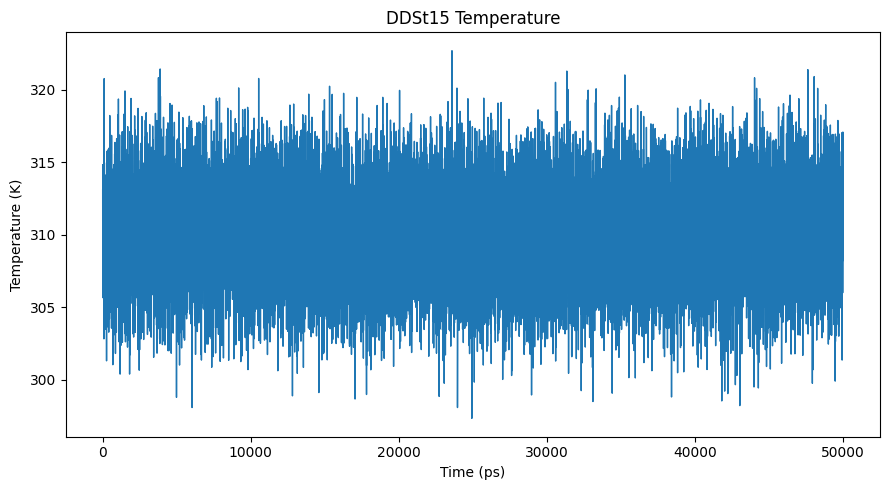

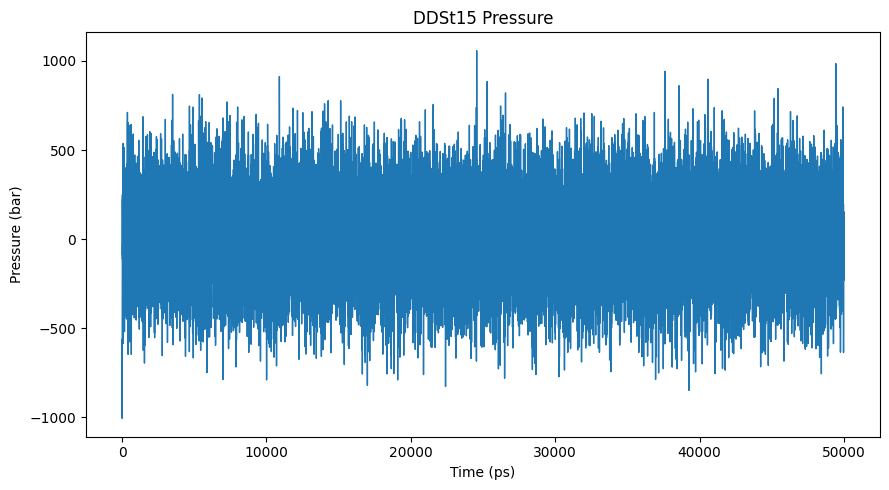


FINAL RESULT
Temperature data: PASS
Temperature validation: PASS
Pressure data: PASS
Pressure validation: PASS

OVERALL: PASS


In [80]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# Input files
result_root = Path(r"D:\uni\HAP\Slab+ force field\SN\Result of DDSt15")
temperature_file = result_root / "temperature.xvg"
pressure_file = result_root / "pressure.xvg"

# Output directory
analysis_root = Path(r"D:\uni\HAP\Slab+ force field\SN\analysis of DDSt15")
output_dir = analysis_root / "Step_3_Equilibration"
output_dir.mkdir(parents=True, exist_ok=True)


def read_xvg(file_path):
    """Read numerical data from a GROMACS XVG file."""
    data = []
    with file_path.open("r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith(("#", "@")):
                continue

            parts = line.split()
            if len(parts) < 2:
                continue

            try:
                time = float(parts[0])
                value = float(parts[1])
            except ValueError:
                continue

            data.append([time, value])

    data = np.asarray(data, dtype=float)
    if data.ndim != 2 or data.shape[1] < 2 or len(data) == 0:
        raise ValueError(f"No valid numerical data found in {file_path.name}")

    return data[:, 0], data[:, 1]


def validate_series(time, values, name):
    """Validate time and measurement values."""
    time_finite = np.isfinite(time).all()
    values_finite = np.isfinite(values).all()
    
    if len(time) > 1:
        dt = np.diff(time)
        time_ordered = np.all(dt >= 0)
    else:
        time_ordered = True

    if not time_finite:
        raise ValueError(f"Invalid time values detected in {name}.")

    if not values_finite:
        raise ValueError(f"Invalid values detected in {name}.")

    if not time_ordered:
        raise ValueError(f"Time values are not ordered in {name}.")

    return time_finite, values_finite, time_ordered


def analyze_stability(time, values):
    """Compare early and late portions of the trajectory."""
    n = len(values)
    early_end = max(1, int(0.10 * n))
    late_start = min(n - 1, int(0.90 * n))
    early = values[:early_end]
    late = values[late_start:]
    return {
        "overall_mean": np.mean(values),
        "overall_std": np.std(values),
        "overall_min": np.min(values),
        "overall_max": np.max(values),
        "early_mean": np.mean(early),
        "early_std": np.std(early),
        "late_mean": np.mean(late),
        "late_std": np.std(late),
        "early_start_time": time[0],
        "early_end_time": time[early_end - 1],
        "late_start_time": time[late_start],
        "late_end_time": time[-1],
    }


# ------------------------------------------------------------
# Read data
# ------------------------------------------------------------

temperature_time, temperature = read_xvg(temperature_file)
pressure_time, pressure = read_xvg(pressure_file)

# ------------------------------------------------------------
# Validate data
# ------------------------------------------------------------

temp_checks = validate_series( temperature_time,temperature,"temperature")
pressure_checks = validate_series( pressure_time, pressure, "pressure")

# ------------------------------------------------------------
# Analyze stability
# ------------------------------------------------------------

temp_stats = analyze_stability( temperature_time, temperature)
pressure_stats = analyze_stability(pressure_time,pressure)

# ------------------------------------------------------------
# Print results
# ------------------------------------------------------------

print("=" * 70)
print("DDSt15 EQUILIBRATION VALIDATION")
print("=" * 70)

print("\nTEMPERATURE")
print("-" * 70)
print(f"Number of data points: {len(temperature)}")
print(f"Time range: {temperature_time[0]:.3f} - {temperature_time[-1]:.3f} ps")
print(f"Temperature range: {temp_stats['overall_min']:.3f} - {temp_stats['overall_max']:.3f} K")
print(f"Mean temperature: {temp_stats['overall_mean']:.3f} K")
print(f"Standard deviation: {temp_stats['overall_std']:.3f} K")
print(f"Early 10% mean: {temp_stats['early_mean']:.3f} K")
print(f"Late 10% mean: {temp_stats['late_mean']:.3f} K")
print(f"Early 10% SD: {temp_stats['early_std']:.3f} K")
print(f"Late 10% SD: {temp_stats['late_std']:.3f} K")

print("\nTemperature validation:")
print(f"Time values: {'PASS' if temp_checks[0] else 'FAIL'}")
print(f"Temperature values: {'PASS' if temp_checks[1] else 'FAIL'}")
print(f"Time ordering: {'PASS' if temp_checks[2] else 'FAIL'}")

print("\nPRESSURE")
print("-" * 70)
print(f"Number of data points: {len(pressure)}")
print(f"Time range: {pressure_time[0]:.3f} - {pressure_time[-1]:.3f} ps")
print(f"Pressure range: {pressure_stats['overall_min']:.3f} - {pressure_stats['overall_max']:.3f} bar")
print(f"Mean pressure: {pressure_stats['overall_mean']:.3f} bar")
print(f"Standard deviation: {pressure_stats['overall_std']:.3f} bar")
print(f"Early 10% mean: {pressure_stats['early_mean']:.3f} bar")
print(f"Late 10% mean: {pressure_stats['late_mean']:.3f} bar")
print(f"Early 10% SD: {pressure_stats['early_std']:.3f} bar")
print(f"Late 10% SD: {pressure_stats['late_std']:.3f} bar")

print("\nPressure validation:")
print(f"Time values: {'PASS' if pressure_checks[0] else 'FAIL'}")
print(f"Pressure values: {'PASS' if pressure_checks[1] else 'FAIL'}")
print(f"Time ordering: {'PASS' if pressure_checks[2] else 'FAIL'}")

# ------------------------------------------------------------
# Create temperature plot
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))
plt.plot( temperature_time,temperature,linewidth=1)
plt.xlabel("Time (ps)")
plt.ylabel("Temperature (K)")
plt.title("DDSt15 Temperature")
plt.tight_layout()
temperature_figure = output_dir / "temperature.png"
plt.savefig( temperature_figure, dpi=300,bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# Create pressure plot
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))
plt.plot(pressure_time,pressure,linewidth=1)
plt.xlabel("Time (ps)")
plt.ylabel("Pressure (bar)")
plt.title("DDSt15 Pressure")
plt.tight_layout()
pressure_figure = output_dir / "pressure.png"
plt.savefig(pressure_figure, dpi=300,bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# Final validation
# ------------------------------------------------------------

overall_pass = (len(temperature) > 0 and len(pressure) > 0 and all(temp_checks)  and all(pressure_checks))
print("\n" + "=" * 70)
print("FINAL RESULT")
print("=" * 70)
print(f"Temperature data: {'PASS' if len(temperature) > 0 else 'FAIL'}")
print(f"Temperature validation: {'PASS' if all(temp_checks) else 'FAIL'}")
print(f"Pressure data: {'PASS' if len(pressure) > 0 else 'FAIL'}")
print(f"Pressure validation: {'PASS' if all(pressure_checks) else 'FAIL'}")
print(f"\nOVERALL: {'PASS' if overall_pass else 'FAIL'}")
print("=" * 70)

## DDSt15 RMSD Analysis — Step 4

This step evaluates structural deviations of DDSt15 throughout the production trajectory.

### Tasks

- Analyze the backbone RMSD
- Check RMSD data integrity and time ordering
- Determine the RMSD range and mean value
- Examine structural stability over time
- Identify possible long-term drift or stabilization
- Save the RMSD plot for documentation

DDSt15 RMSD ANALYSIS

Data validation:
Number of data points: 501
Time values: PASS
RMSD values: PASS
Time ordering: PASS

Trajectory range:
Start time: 0.000 ps
End time: 50000.000 ps

RMSD statistics:
Minimum: 0.000000 nm
Maximum: 0.407471 nm
Mean: 0.301453 nm
Standard deviation: 0.076945 nm
Minimum RMSD time: 0.000 ps
Maximum RMSD time: 39600.000 ps

Early vs late trajectory:
Early 10% mean: 0.156884 nm
Early 10% SD: 0.046585 nm
Late 10% mean: 0.375274 nm
Late 10% SD: 0.012595 nm
Late - Early mean difference: 0.218389 nm


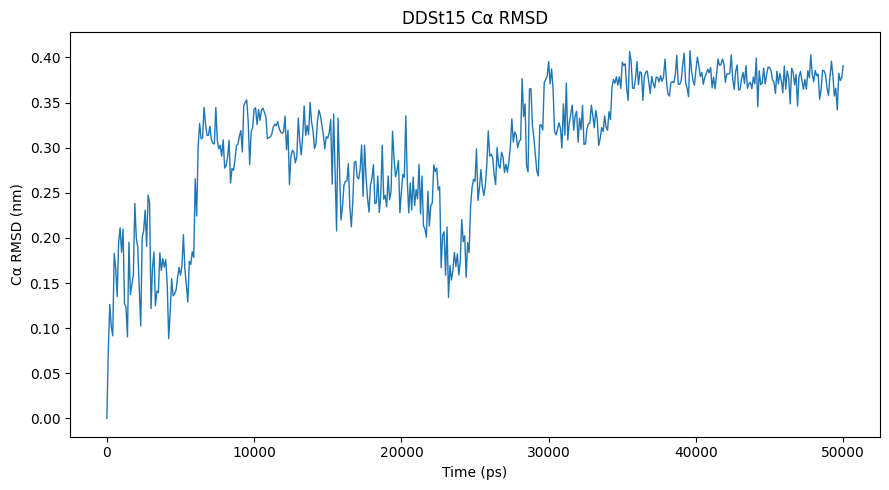


FINAL RESULT
Data points: PASS
Time values: PASS
RMSD values: PASS
Time ordering: PASS

OVERALL: PASS


In [87]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# Input file
result_root = Path(r"D:\uni\HAP\Slab+ force field\SN\Result of DDSt15")
input_xvg = result_root / "rmsd_ca.xvg"

# Output directory
analysis_root = Path(r"D:\uni\HAP\Slab+ force field\SN\analysis of DDSt15")
output_dir = analysis_root / "Step_4_RMSD"
output_dir.mkdir(parents=True, exist_ok=True)


def read_xvg(file_path):
    """Read numerical data from a GROMACS XVG file."""
    data = []
    with file_path.open("r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            line = line.strip()

            if not line or line.startswith(("#", "@")):
                continue

            parts = line.split()

            if len(parts) < 2:
                continue

            try:
                time = float(parts[0])
                rmsd = float(parts[1])
            except ValueError:
                continue

            data.append([time, rmsd])

    data = np.asarray(data, dtype=float)

    if data.ndim != 2 or data.shape[1] < 2 or len(data) == 0:
        raise ValueError("No valid numerical data were found in the XVG file.")

    return data[:, 0], data[:, 1]


# ------------------------------------------------------------
# Read RMSD data
# ------------------------------------------------------------

time, rmsd = read_xvg(input_xvg)

# ------------------------------------------------------------
# Validate data
# ------------------------------------------------------------

time_finite = np.isfinite(time).all()
rmsd_finite = np.isfinite(rmsd).all()

if len(time) > 1:
    dt = np.diff(time)
    time_ordered = np.all(dt >= 0)
else:
    time_ordered = True

if not time_finite:
    raise ValueError("Invalid time values detected.")

if not rmsd_finite:
    raise ValueError("Invalid RMSD values detected.")

if not time_ordered:
    raise ValueError("Time values are not ordered.")

# ------------------------------------------------------------
# Basic statistics
# ------------------------------------------------------------

n_points = len(rmsd)

time_start = time[0]
time_end = time[-1]

rmsd_min = rmsd.min()
rmsd_max = rmsd.max()
rmsd_mean = rmsd.mean()
rmsd_std = rmsd.std()

min_index = np.argmin(rmsd)
max_index = np.argmax(rmsd)

time_at_min = time[min_index]
time_at_max = time[max_index]

# ------------------------------------------------------------
# Early vs late trajectory comparison
# ------------------------------------------------------------

early_end = max(1, int(0.10 * n_points))
late_start = min(n_points - 1, int(0.90 * n_points))

early_rmsd = rmsd[:early_end]
late_rmsd = rmsd[late_start:]

early_mean = early_rmsd.mean()
early_std = early_rmsd.std()

late_mean = late_rmsd.mean()
late_std = late_rmsd.std()

mean_difference = late_mean - early_mean

# ------------------------------------------------------------
# Print results
# ------------------------------------------------------------

print("=" * 70)
print("DDSt15 RMSD ANALYSIS")
print("=" * 70)

print("\nData validation:")
print(f"Number of data points: {n_points}")
print(f"Time values: {'PASS' if time_finite else 'FAIL'}")
print(f"RMSD values: {'PASS' if rmsd_finite else 'FAIL'}")
print(f"Time ordering: {'PASS' if time_ordered else 'FAIL'}")

print("\nTrajectory range:")
print(f"Start time: {time_start:.3f} ps")
print(f"End time: {time_end:.3f} ps")

print("\nRMSD statistics:")
print(f"Minimum: {rmsd_min:.6f} nm")
print(f"Maximum: {rmsd_max:.6f} nm")
print(f"Mean: {rmsd_mean:.6f} nm")
print(f"Standard deviation: {rmsd_std:.6f} nm")
print(f"Minimum RMSD time: {time_at_min:.3f} ps")
print(f"Maximum RMSD time: {time_at_max:.3f} ps")

print("\nEarly vs late trajectory:")
print(f"Early 10% mean: {early_mean:.6f} nm")
print(f"Early 10% SD: {early_std:.6f} nm")
print(f"Late 10% mean: {late_mean:.6f} nm")
print(f"Late 10% SD: {late_std:.6f} nm")
print(f"Late - Early mean difference: {mean_difference:.6f} nm")

# ------------------------------------------------------------
# Plot RMSD
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

plt.plot(time, rmsd, linewidth=1)
plt.xlabel("Time (ps)")
plt.ylabel("Cα RMSD (nm)")
plt.title("DDSt15 Cα RMSD")
plt.tight_layout()
figure_path = output_dir / "rmsd_ca.png"
plt.savefig( figure_path,dpi=300,bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# Final result
# ------------------------------------------------------------

overall_pass = (
    n_points > 0
    and time_finite
    and rmsd_finite
    and time_ordered
)

print("\n" + "=" * 70)
print("FINAL RESULT")
print("=" * 70)
print(f"Data points: {'PASS' if n_points > 0 else 'FAIL'}")
print(f"Time values: {'PASS' if time_finite else 'FAIL'}")
print(f"RMSD values: {'PASS' if rmsd_finite else 'FAIL'}")
print(f"Time ordering: {'PASS' if time_ordered else 'FAIL'}")
print(f"\nOVERALL: {'PASS' if overall_pass else 'FAIL'}")
print("=" * 70)

## DDSt15 RMSF Analysis — Step 5

This step evaluates the residue-level flexibility of DDSt15 during the production trajectory.

### Tasks

- Analyze residue-wise RMSF
- Identify flexible and relatively stable regions
- Check RMSF data integrity
- Plot RMSF along the DDSt15 sequence
- Identify residues with comparatively high fluctuations

DDSt15 RMSF ANALYSIS

Data validation:
Number of data points: 15
Residue indices finite: PASS
RMSF values finite: PASS
Residue indices integer-like: PASS
Residue ordering: PASS

RMSF statistics:
Minimum: 0.134000 nm
Maximum: 0.548300 nm
Mean: 0.247627 nm
Standard deviation: 0.126794 nm

Minimum RMSF residue index: 27
Maximum RMSF residue index: 34

Residue-wise RMSF:
Residue 20 (UNKNOWN): 0.416200 nm
Residue 21 (UNKNOWN): 0.216900 nm
Residue 22 (UNKNOWN): 0.154900 nm
Residue 23 (UNKNOWN): 0.148100 nm
Residue 24 (UNKNOWN): 0.139700 nm
Residue 25 (UNKNOWN): 0.156600 nm
Residue 26 (UNKNOWN): 0.181000 nm
Residue 27 (UNKNOWN): 0.134000 nm
Residue 28 (UNKNOWN): 0.241200 nm
Residue 29 (UNKNOWN): 0.239900 nm
Residue 30 (UNKNOWN): 0.166600 nm
Residue 31 (UNKNOWN): 0.160300 nm
Residue 32 (UNKNOWN): 0.433200 nm
Residue 33 (UNKNOWN): 0.377500 nm
Residue 34 (UNKNOWN): 0.548300 nm

Highest RMSF residues:
1. Residue 34 (UNKNOWN) — 0.548300 nm
2. Residue 32 (UNKNOWN) — 0.433200 nm
3. Residue 20 (UNKNO

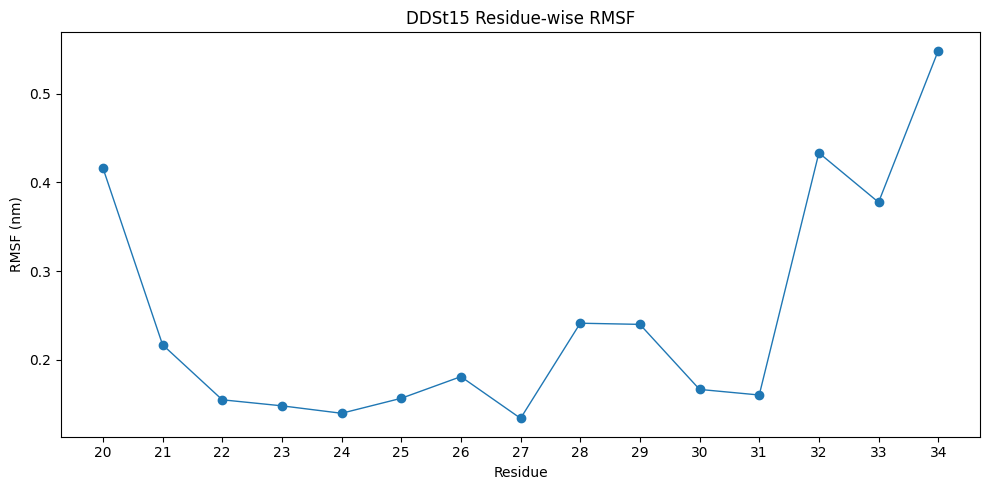


FINAL RESULT
Data points: PASS
Residue indices: PASS
RMSF values: PASS
Residue ordering: PASS

OVERALL: PASS


In [104]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# Input file
result_root = Path(r"D:\uni\HAP\Slab+ force field\SN\Result of DDSt15")
input_xvg = result_root / "rmsf_ddst15.xvg"

# Output directory
analysis_root = Path(r"D:\uni\HAP\Slab+ force field\SN\analysis of DDSt15")
output_dir = analysis_root / "Step_5_RMSF"
output_dir.mkdir(parents=True, exist_ok=True)


def read_xvg(file_path):
    """Read numerical data from a GROMACS XVG file."""
    data = []
    with file_path.open("r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            line = line.strip()

            if not line or line.startswith(("#", "@")):
                continue

            parts = line.split()

            if len(parts) < 2:
                continue

            try:
                x_value = float(parts[0])
                rmsf_value = float(parts[1])
            except ValueError:
                continue

            data.append([x_value, rmsf_value])

    data = np.asarray(data, dtype=float)

    if data.ndim != 2 or data.shape[1] < 2 or len(data) == 0:
        raise ValueError("No valid numerical data were found in the XVG file.")

    return data[:, 0], data[:, 1]


# ------------------------------------------------------------
# Read RMSF data
# ------------------------------------------------------------

residue_index, rmsf = read_xvg(input_xvg)

# ------------------------------------------------------------
# Validate data
# ------------------------------------------------------------

index_finite = np.isfinite(residue_index).all()
rmsf_finite = np.isfinite(rmsf).all()

index_integer_like = np.allclose(residue_index, np.round(residue_index))
index_ordered = (
    np.all(np.diff(residue_index) >= 0)
    if len(residue_index) > 1
    else True
)

if not index_finite:
    raise ValueError("Invalid residue index values detected.")

if not rmsf_finite:
    raise ValueError("Invalid RMSF values detected.")

if not index_ordered:
    raise ValueError("Residue indices are not ordered.")

# ------------------------------------------------------------
# Basic statistics
# ------------------------------------------------------------

n_points = len(rmsf)

rmsf_min = rmsf.min()
rmsf_max = rmsf.max()
rmsf_mean = rmsf.mean()
rmsf_std = rmsf.std()

min_index = np.argmin(rmsf)
max_index = np.argmax(rmsf)

residue_at_min = residue_index[min_index]
residue_at_max = residue_index[max_index]

# ------------------------------------------------------------
# Sequence information
# ------------------------------------------------------------

sequence = [
    "ASP", "ASP", "ASP", "GLU", "GLU",
    "LYS", "PHE", "LEU", "ARG", "ARG",
    "ILE", "GLY", "ARG", "PHE", "GLY"
]

# ------------------------------------------------------------
# Print results
# ------------------------------------------------------------

print("=" * 70)
print("DDSt15 RMSF ANALYSIS")
print("=" * 70)

print("\nData validation:")
print(f"Number of data points: {n_points}")
print(f"Residue indices finite: {'PASS' if index_finite else 'FAIL'}")
print(f"RMSF values finite: {'PASS' if rmsf_finite else 'FAIL'}")
print(f"Residue indices integer-like: {'PASS' if index_integer_like else 'CHECK'}")
print(f"Residue ordering: {'PASS' if index_ordered else 'FAIL'}")

print("\nRMSF statistics:")
print(f"Minimum: {rmsf_min:.6f} nm")
print(f"Maximum: {rmsf_max:.6f} nm")
print(f"Mean: {rmsf_mean:.6f} nm")
print(f"Standard deviation: {rmsf_std:.6f} nm")

print(f"\nMinimum RMSF residue index: {residue_at_min:.0f}")
print(f"Maximum RMSF residue index: {residue_at_max:.0f}")

# ------------------------------------------------------------
# Map residue indices to DDSt15 residues
# ------------------------------------------------------------

print("\nResidue-wise RMSF:")

for i, (idx, value) in enumerate(zip(residue_index, rmsf)):

    residue_number = int(round(idx))

    if 1 <= residue_number <= len(sequence):
        residue_name = sequence[residue_number - 1]
    else:
        residue_name = "UNKNOWN"

    print(
        f"Residue {residue_number:2d} "
        f"({residue_name:3s}): "
        f"{value:.6f} nm"
    )

# ------------------------------------------------------------
# Identify highest-flexibility residues
# ------------------------------------------------------------

sorted_indices = np.argsort(rmsf)[::-1]

top_n = min(5, len(rmsf))

print("\nHighest RMSF residues:")

for rank in range(top_n):

    idx = sorted_indices[rank]
    residue_number = int(round(residue_index[idx]))

    if 1 <= residue_number <= len(sequence):
        residue_name = sequence[residue_number - 1]
    else:
        residue_name = "UNKNOWN"

    print(
        f"{rank + 1}. Residue {residue_number} "
        f"({residue_name}) — "
        f"{rmsf[idx]:.6f} nm"
    )

# ------------------------------------------------------------
# Plot RMSF
# ------------------------------------------------------------

labels = []

for idx in residue_index:
    residue_number = int(round(idx))

    if 1 <= residue_number <= len(sequence):
        labels.append(f"{residue_number}-{sequence[residue_number - 1]}" )
    else:
        labels.append(str(residue_number))

plt.figure(figsize=(10, 5))
plt.plot(residue_index, rmsf,marker="o", linewidth=1)
plt.xlabel("Residue")
plt.ylabel("RMSF (nm)")
plt.title("DDSt15 Residue-wise RMSF")
plt.xticks( residue_index, [str(int(x)) for x in residue_index])
plt.tight_layout()
figure_path = output_dir / "rmsf.png"
plt.savefig(figure_path,dpi=300,bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# Final result
# ------------------------------------------------------------

overall_pass = (
    n_points > 0
    and index_finite
    and rmsf_finite
    and index_ordered
)

print("\n" + "=" * 70)
print("FINAL RESULT")
print("=" * 70)

print(f"Data points: {'PASS' if n_points > 0 else 'FAIL'}")
print(f"Residue indices: {'PASS' if index_finite else 'FAIL'}")
print(f"RMSF values: {'PASS' if rmsf_finite else 'FAIL'}")
print(f"Residue ordering: {'PASS' if index_ordered else 'FAIL'}")

print(f"\nOVERALL: {'PASS' if overall_pass else 'FAIL'}")
print("=" * 70)

# DDSt15 Secondary Structure Analysis — Step 6

This step evaluates the secondary-structure behavior of DDSt15 throughout the 50-ns production trajectory.

### Tasks

- Assign secondary-structure states at the residue level throughout the trajectory
- Quantify the population of each secondary-structure class
- Examine the temporal evolution of secondary structure
- Identify residues or regions with persistent or variable secondary-structure assignments
- Assess whether DDSt15 maintains a persistent secondary-structure pattern or undergoes substantial conformational transitions
- Compare the secondary-structure behavior with the structural changes observed in RMSD and RMSF analyses

### Analysis Scope

The analysis will be performed specifically for DDSt15 residues 20–34 (15 residues) using the production trajectory.

### Expected Outputs

- Residue-level secondary-structure assignment
- Secondary-structure population statistics
- Time-dependent secondary-structure analysis
- Residue-wise secondary-structure visualization
- Summary of the dominant and transient structural states

In [122]:
# Inspect all unique DSSP codes and their frequencies

unique_codes, counts = np.unique( ddst15_dssp,return_counts=True)
print("=" * 70)
print("DSSP CODE VALIDATION")
print("=" * 70)

total_assignments = ddst15_dssp.size

for code, count in zip(unique_codes, counts):
    print(
        f"Code {repr(code):>6}: "
        f"{count:5d} "
        f"({100 * count / total_assignments:6.2f}%)"
    )

print("-" * 70)
print(f"Total residue-frame assignments: {total_assignments}")

valid_codes = {"H", "B", "E", "G", "I", "T", "S", "-"}

unknown_mask = ~np.isin(ddst15_dssp, list(valid_codes))
unknown_count = np.sum(unknown_mask)

print(f"Valid assignments:   {total_assignments - unknown_count}")
print(f"Unknown assignments: {unknown_count}")
print(f"Unknown fraction:     {100 * unknown_count / total_assignments:.2f}%")

print("-" * 70)

if unknown_count == 0:
    print("DSSP code validation: PASS")
else:
    print("DSSP code validation: CHECK REQUIRED")

print("=" * 70)

DSSP CODE VALIDATION
Code np.str_(' '):  1730 ( 23.02%)
Code np.str_('B'):    26 (  0.35%)
Code np.str_('E'):    11 (  0.15%)
Code np.str_('G'):    80 (  1.06%)
Code np.str_('H'):  4647 ( 61.84%)
Code np.str_('I'):    30 (  0.40%)
Code np.str_('S'):   407 (  5.42%)
Code np.str_('T'):   584 (  7.77%)
----------------------------------------------------------------------
Total residue-frame assignments: 7515
Valid assignments:   5785
Unknown assignments: 1730
Unknown fraction:     23.02%
----------------------------------------------------------------------
DSSP code validation: CHECK REQUIRED


In [128]:
# Locate unassigned DSSP states by residue

print("=" * 70)
print("UNASSIGNED DSSP STATES BY RESIDUE")
print("=" * 70)

ddst15_residue_indices = [
    i for i, residue in enumerate(traj.topology.residues)
    if residue.resSeq >= 20 and residue.resSeq <= 34
]

for i, residue_index in enumerate(ddst15_residue_indices):
    residue = traj.topology.residue(residue_index)
    residue_codes = ddst15_dssp[:, i]

    unknown_count = np.sum(residue_codes == " ")
    valid_count = len(residue_codes) - unknown_count

    print(
        f"Residue {residue.resSeq:2d} "
        f"({str(residue.name):>3s}) : "
        f"valid = {valid_count:3d} "
        f"unknown = {unknown_count:3d} "
        f"({100 * unknown_count / len(residue_codes):6.2f}%)"
    )

print("=" * 70)

UNASSIGNED DSSP STATES BY RESIDUE
Residue 20 (ASP) : valid =   0 unknown = 501 (100.00%)
Residue 21 (ASP) : valid = 269 unknown = 232 ( 46.31%)
Residue 22 (ASP) : valid = 496 unknown =   5 (  1.00%)
Residue 23 (GLU) : valid = 501 unknown =   0 (  0.00%)
Residue 24 (GLU) : valid = 498 unknown =   3 (  0.60%)
Residue 25 (LYS) : valid = 501 unknown =   0 (  0.00%)
Residue 26 (PHE) : valid = 501 unknown =   0 (  0.00%)
Residue 27 (LEU) : valid = 501 unknown =   0 (  0.00%)
Residue 28 (ARG) : valid = 501 unknown =   0 (  0.00%)
Residue 29 (ARG) : valid = 501 unknown =   0 (  0.00%)
Residue 30 (ILE) : valid = 497 unknown =   4 (  0.80%)
Residue 31 (GLY) : valid = 478 unknown =  23 (  4.59%)
Residue 32 (ARG) : valid = 437 unknown =  64 ( 12.77%)
Residue 33 (PHE) : valid = 104 unknown = 397 ( 79.24%)
Residue 34 (GLY) : valid =   0 unknown = 501 (100.00%)


In [130]:
# Check simplified DSSP assignment

ddst15_dssp_simple = md.compute_dssp( traj, simplified=True)

ddst15_dssp_simple = ddst15_dssp_simple[
    :,
    ddst15_residue_indices
]

unique_codes, counts = np.unique( ddst15_dssp_simple, return_counts=True)
print("=" * 70)
print("SIMPLIFIED DSSP VALIDATION")
print("=" * 70)
total = ddst15_dssp_simple.size
for code, count in zip(unique_codes, counts):
    print(
        f"Code {repr(code):>6}: "
        f"{count:5d} "
        f"({100 * count / total:6.2f}%)"
    )

print("-" * 70)
print(f"Total assignments: {total}")
print("=" * 70)

SIMPLIFIED DSSP VALIDATION
Code np.str_('C'):  2721 ( 36.21%)
Code np.str_('E'):    37 (  0.49%)
Code np.str_('H'):  4757 ( 63.30%)
----------------------------------------------------------------------
Total assignments: 7515


In [132]:
# Calculate simplified secondary-structure populations by residue

print("=" * 70)
print("SIMPLIFIED DSSP BY RESIDUE")
print("=" * 70)

simple_codes = ["H", "E", "C"]

for i, residue_index in enumerate(ddst15_residue_indices):
    residue = traj.topology.residue(residue_index)
    residue_codes = ddst15_dssp_simple[:, i]

    print(f"Residue {residue.resSeq:2d} ({residue.name:>3s}) : ", end="")

    for code in simple_codes:
        percentage = 100 * np.sum(residue_codes == code) / len(residue_codes)
        print(f"{code}={percentage:6.2f}%  ", end="")

    print()

print("=" * 70)

SIMPLIFIED DSSP BY RESIDUE
Residue 20 (ASP) : H=  0.00%  E=  0.00%  C=100.00%  
Residue 21 (ASP) : H= 50.30%  E=  0.40%  C= 49.30%  
Residue 22 (ASP) : H= 82.63%  E=  0.40%  C= 16.97%  
Residue 23 (GLU) : H= 85.43%  E=  0.20%  C= 14.37%  
Residue 24 (GLU) : H= 90.02%  E=  0.20%  C=  9.78%  
Residue 25 (LYS) : H= 92.22%  E=  0.60%  C=  7.19%  
Residue 26 (PHE) : H= 93.01%  E=  0.80%  C=  6.19%  
Residue 27 (LEU) : H= 93.81%  E=  0.40%  C=  5.79%  
Residue 28 (ARG) : H= 96.01%  E=  0.40%  C=  3.59%  
Residue 29 (ARG) : H= 91.62%  E=  0.40%  C=  7.98%  
Residue 30 (ILE) : H= 84.63%  E=  0.80%  C= 14.57%  
Residue 31 (GLY) : H= 55.89%  E=  1.20%  C= 42.91%  
Residue 32 (ARG) : H= 31.74%  E=  1.00%  C= 67.27%  
Residue 33 (PHE) : H=  2.20%  E=  0.60%  C= 97.21%  
Residue 34 (GLY) : H=  0.00%  E=  0.00%  C=100.00%  


In [141]:
import importlib.util
packages = [ "MDAnalysis","mdtraj","Bio","pandas", "numpy", "matplotlib"]
print("=" * 60)
print("AVAILABLE PYTHON PACKAGES")
print("=" * 60)
for package in packages:
    status = importlib.util.find_spec(package) is not None
    print(f"{package:15s}: {'AVAILABLE' if status else 'NOT INSTALLED'}")

AVAILABLE PYTHON PACKAGES
MDAnalysis     : NOT INSTALLED
mdtraj         : AVAILABLE
Bio            : NOT INSTALLED
pandas         : AVAILABLE
numpy          : AVAILABLE
matplotlib     : AVAILABLE


DDSt15 SECONDARY STRUCTURE ANALYSIS — STEP 6

Input directory:
D:\uni\HAP\Slab+ force field\SN\Result of DDSt15

Output directory:
D:\uni\HAP\Slab+ force field\SN\analysis of DDSt15\Step_6_Secondary_Structure

Input files: PASS

[1] Loading trajectory...
Total frames: 501
Total atoms:  10905
Time range:   0.0 - 50000.0 ps

[2] Selecting DDSt15 residues 20–34...
Number of selected residues: 15

Selected residues:
  20  ASP
  21  ASP
  22  ASP
  23  GLU
  24  GLU
  25  LYS
  26  PHE
  27  LEU
  28  ARG
  29  ARG
  30  ILE
  31  GLY
  32  ARG
  33  PHE
  34  GLY

DDSt15 selection validation:
DDSt15 atoms:  255
DDSt15 frames: 501
DDSt15 selection: PASS

[3] Computing DSSP secondary structure...
DSSP assignment completed.
DSSP array shape: (501, 15)
DSSP dimensions: PASS

[4] Calculating overall secondary-structure populations...

Overall secondary-structure population:
State  Description  Count  Percentage
    H  Alpha helix   4647   61.836327
    B  Beta bridge     26    0.345975
    E  B

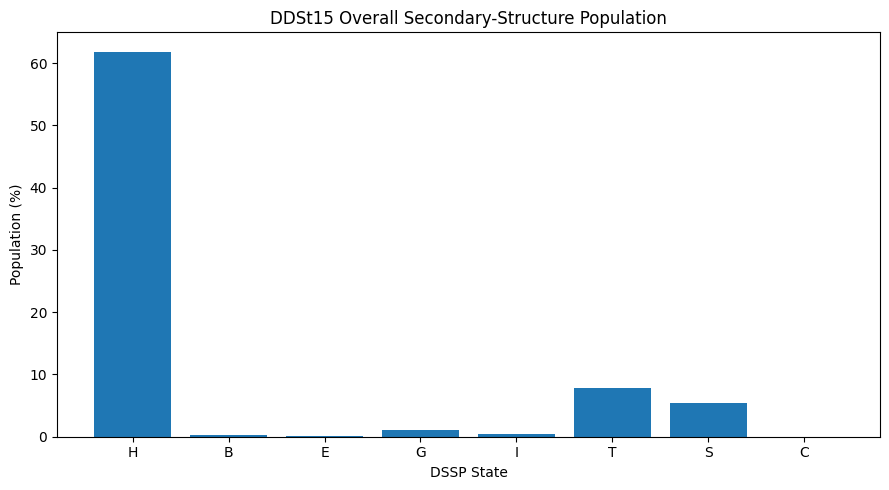


[10] Creating Figure 2...


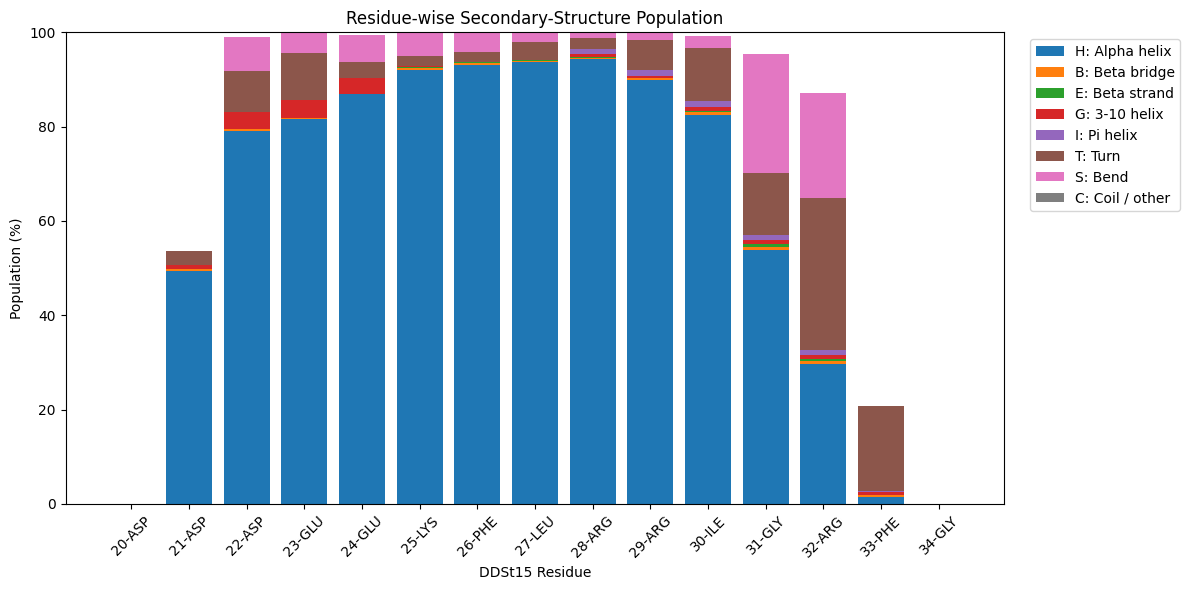


[11] Creating Figure 3...


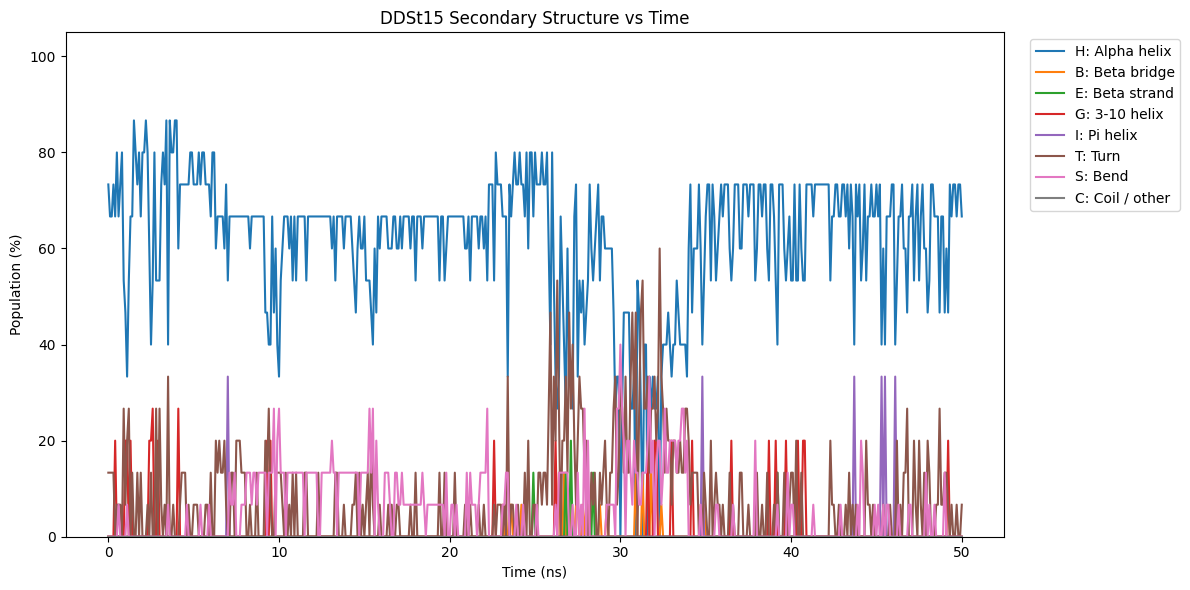


[12] Creating Figure 4...
DSSP numeric matrix:
Shape: (501, 15)
Dtype: int8


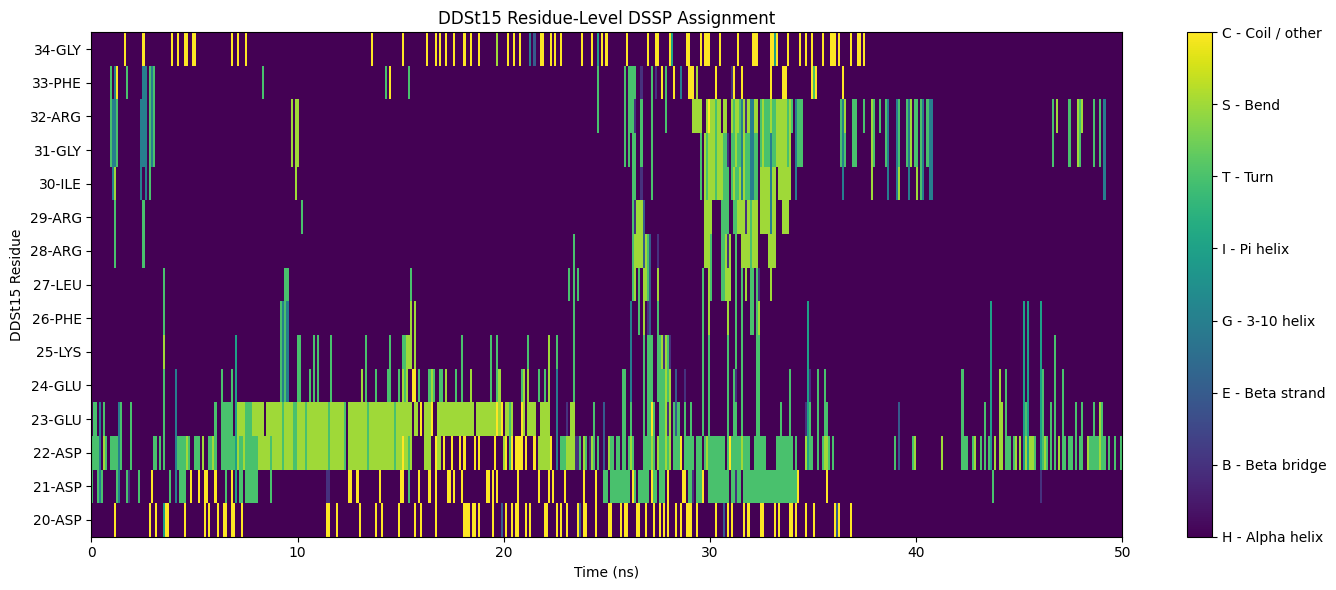


Figure 4 saved successfully.

SECONDARY-STRUCTURE SUMMARY

Frames analyzed: 501
Residues analyzed: 15
Trajectory duration: 50.00 ns

Overall secondary-structure populations:
  H (Alpha helix): 61.84%
  B (Beta bridge): 0.35%
  E (Beta strand): 0.15%
  G (3-10 helix): 1.06%
  I (Pi helix): 0.40%
  T (Turn): 7.77%
  S (Bend): 5.42%
  C (Coil / other): 0.00%

Dominant secondary structure per residue:
  20 ASP: H (0.00%)
  21 ASP: H (49.50%)
  22 ASP: H (79.04%)
  23 GLU: H (81.64%)
  24 GLU: H (86.83%)
  25 LYS: H (92.02%)
  26 PHE: H (93.01%)
  27 LEU: H (93.81%)
  28 ARG: H (94.41%)
  29 ARG: H (89.82%)
  30 ILE: H (82.44%)
  31 GLY: H (53.89%)
  32 ARG: T (32.14%)
  33 PHE: T (17.96%)
  34 GLY: H (0.00%)

ANALYSIS COMPLETE

All outputs saved to:
D:\uni\HAP\Slab+ force field\SN\analysis of DDSt15\Step_6_Secondary_Structure


In [151]:
# ============================================================
# DDSt15 SECONDARY STRUCTURE ANALYSIS — STEP 6
# ============================================================

import mdtraj as md
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


# ============================================================
#  Paths
# ============================================================

INPUT_DIR = Path( r"D:\uni\HAP\Slab+ force field\SN\Result of DDSt15")
ANALYSIS_DIR = Path( r"D:\uni\HAP\Slab+ force field\SN\analysis of DDSt15")
OUTPUT_DIR = ANALYSIS_DIR / "Step_6_Secondary_Structure"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
TRAJ_FILE = INPUT_DIR / "prod.xtc"
TOPOLOGY_FILE = INPUT_DIR / "prod.gro"

# ============================================================
#  Check input files
# ============================================================

print("=" * 70)
print("DDSt15 SECONDARY STRUCTURE ANALYSIS — STEP 6")
print("=" * 70)
print("\nInput directory:")
print(INPUT_DIR)
print("\nOutput directory:")
print(OUTPUT_DIR)
if not TRAJ_FILE.exists():
    raise FileNotFoundError(f"Trajectory file not found:\n{TRAJ_FILE}" )

if not TOPOLOGY_FILE.exists():
    raise FileNotFoundError( f"Topology file not found:\n{TOPOLOGY_FILE}" )

print("\nInput files: PASS")


# ============================================================
#  Load trajectory
# ============================================================

print("\n[1] Loading trajectory...")

traj = md.load( str(TRAJ_FILE),top=str(TOPOLOGY_FILE))

print(f"Total frames: {traj.n_frames}")
print(f"Total atoms:  {traj.n_atoms}")
print(
    f"Time range:   "
    f"{traj.time[0]:.1f} - {traj.time[-1]:.1f} ps"
)


# ============================================================
#  Select DDSt15 residues 20–34
# ============================================================

print("\n[2] Selecting DDSt15 residues 20–34...")

ddst_residues = [
    residue
    for residue in traj.topology.residues
    if 20 <= residue.resSeq <= 34
]

print(f"Number of selected residues: {len(ddst_residues)}")

if len(ddst_residues) != 15:
    raise ValueError(
        f"Expected exactly 15 DDSt15 residues "
        f"(20–34), but found {len(ddst_residues)}."
    )

print("\nSelected residues:")

for residue in ddst_residues:
    print(
        f"  {residue.resSeq:2d}  "
        f"{residue.name}"
    )


# ============================================================
#  Extract DDSt15 trajectory
# ============================================================

ddst_atom_indices = np.array(
    [
        atom.index
        for residue in ddst_residues
        for atom in residue.atoms
    ],
    dtype=int
)

ddst_traj = traj.atom_slice(ddst_atom_indices)

print("\nDDSt15 selection validation:")
print(f"DDSt15 atoms:  {ddst_traj.n_atoms}")
print(f"DDSt15 frames: {ddst_traj.n_frames}")

if ddst_traj.n_frames != traj.n_frames:
    raise ValueError("Frame count changed during atom selection.")

print("DDSt15 selection: PASS")


# ============================================================
#  Secondary-structure assignment
# ============================================================

print("\n[3] Computing DSSP secondary structure...")
dssp = md.compute_dssp(ddst_traj,simplified=False)
print("DSSP assignment completed.")
print(f"DSSP array shape: {dssp.shape}")
expected_shape = (ddst_traj.n_frames, len(ddst_residues))

if dssp.shape != expected_shape:
    raise ValueError(
        f"Unexpected DSSP shape: {dssp.shape}. "
        f"Expected: {expected_shape}"
    )

print("DSSP dimensions: PASS")


# ============================================================
#  DSSP state definitions
# ============================================================

state_names = {
    "H": "Alpha helix",
    "B": "Beta bridge",
    "E": "Beta strand",
    "G": "3-10 helix",
    "I": "Pi helix",
    "T": "Turn",
    "S": "Bend",
    "C": "Coil / other"
}

states = list(state_names.keys())


# ============================================================
#  Overall secondary-structure population
# ============================================================

print("\n[4] Calculating overall secondary-structure populations...")
total_assignments = dssp.size
population_rows = []
for state in states:
    count = np.sum(dssp == state)
    percentage = (100.0 * count / total_assignments )

    population_rows.append({
        "State": state,
        "Description": state_names[state],
        "Count": int(count),
        "Percentage": percentage
    })

population_df = pd.DataFrame( population_rows)
print("\nOverall secondary-structure population:")
print(   population_df.to_string(index=False))

# ============================================================
# Residue-wise secondary-structure population
# ============================================================

print(
    "\n[5] Calculating residue-wise "
    "secondary-structure populations..."
)

residue_rows = []
for i, residue in enumerate(ddst_residues):

    row = { "Residue_Number": residue.resSeq,"Residue_Name": residue.name }

    for state in states:
        row[state] = (  100.0 * np.sum(dssp[:, i] == state) / dssp.shape[0])

    residue_rows.append(row)

residue_df = pd.DataFrame(residue_rows)

print("\nResidue-wise populations:")
print( residue_df.to_string(index=False))

# ============================================================
# Dominant secondary structure per residue
# ============================================================

print(
    "\n[6] Determining dominant "
    "secondary structure per residue..."
)

dominant_rows = []
for i, residue in enumerate(ddst_residues):
    counts = { state: np.sum(dssp[:, i] == state)for state in states }
    dominant_state = max( counts,key=counts.get)
    dominant_population = ( 100.0 * counts[dominant_state] / dssp.shape[0] )
    dominant_rows.append({
        "Residue_Number": residue.resSeq,
        "Residue_Name": residue.name,
        "Dominant_State": dominant_state,
        "Dominant_State_Description":
            state_names[dominant_state],
        "Population_Percent":
            dominant_population
    })

dominant_df = pd.DataFrame( dominant_rows)
print("\nDominant state per residue:")
print( dominant_df.to_string(index=False))


# ============================================================
#  Time-dependent secondary structure
# ============================================================

print(
    "\n[7] Calculating time-dependent "
    "secondary structure..."
)

time_ns = traj.time / 1000.0
time_rows = []
for frame in range(dssp.shape[0]):
    row = {"Time_ns": time_ns[frame] }
    for state in states:
        row[state] = ( 100.0 * np.sum(dssp[frame] == state) / len(ddst_residues))

    time_rows.append(row)

time_df = pd.DataFrame(  time_rows)
print("Time-dependent analysis completed.")

# ============================================================
#  Frame-wise dominant secondary structure
# ============================================================

frame_dominant_rows = []
for frame in range(dssp.shape[0]):
    counts = {state: np.sum(dssp[frame] == state) for state in states }
    dominant_state = max( counts, key=counts.get )
    frame_dominant_rows.append({
        "Time_ns": time_ns[frame],
        "Dominant_State": dominant_state,
        "Dominant_State_Description":
            state_names[dominant_state],
        "Number_of_Residues":
            int(counts[dominant_state]),
        "Population_Percent":
            100.0
            * counts[dominant_state]
            / len(ddst_residues)
    })

frame_dominant_df = pd.DataFrame(  frame_dominant_rows)

# ============================================================
#  Save numerical results
# ============================================================

print("\n[8] Saving numerical results...")
population_df.to_csv( OUTPUT_DIR / "secondary_structure_population.csv", index=False)
residue_df.to_csv( OUTPUT_DIR / "residue_secondary_structure_population.csv", index=False)
dominant_df.to_csv( OUTPUT_DIR / "dominant_secondary_structure_per_residue.csv", index=False)
time_df.to_csv(OUTPUT_DIR / "secondary_structure_vs_time.csv", index=False)
frame_dominant_df.to_csv(OUTPUT_DIR / "dominant_secondary_structure_vs_time.csv", index=False)
np.save( OUTPUT_DIR / "ddst15_dssp.npy", dssp)
print("CSV and NPY files saved.")


# ============================================================
# Figure 1 — Overall population
# ============================================================

print("\n[9] Creating Figure 1...")
plt.figure(figsize=(9, 5))
plt.bar(population_df["State"],population_df["Percentage"])
plt.xlabel("DSSP State")
plt.ylabel("Population (%)")
plt.title( "DDSt15 Overall Secondary-Structure Population")
plt.tight_layout()
plt.savefig( OUTPUT_DIR /"overall_secondary_structure_population.png", dpi=300, bbox_inches="tight")
plt.savefig( OUTPUT_DIR /"overall_secondary_structure_population.svg", bbox_inches="tight")
plt.show()
plt.close()

# ============================================================
#  Figure 2 — Residue-wise population
# ============================================================

print("\n[10] Creating Figure 2...")
plt.figure(figsize=(12, 6))
x = np.arange(len(ddst_residues))
bottom = np.zeros( len(ddst_residues))
for state in states:
    values = residue_df[state].values
    plt.bar(x, values,bottom=bottom,label=f"{state}: {state_names[state]}")
    bottom += values

plt.xticks( x,[  f"{residue.resSeq}-{residue.name}" for residue in ddst_residues ],rotation=45)
plt.xlabel("DDSt15 Residue")
plt.ylabel("Population (%)")
plt.title( "Residue-wise Secondary-Structure Population")
plt.legend( bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig( OUTPUT_DIR / "residue_secondary_structure_population.png", dpi=300, bbox_inches="tight")
plt.savefig( OUTPUT_DIR / "residue_secondary_structure_population.svg", bbox_inches="tight")
plt.show()
plt.close()


# ============================================================
# Figure 3 — Secondary structure vs time
# ============================================================

print("\n[11] Creating Figure 3...")
plt.figure(figsize=(12, 6))
for state in states:
    plt.plot(time_df["Time_ns"],time_df[state],label=f"{state}: {state_names[state]}" )

plt.xlabel("Time (ns)")
plt.ylabel("Population (%)")
plt.title( "DDSt15 Secondary Structure vs Time")
plt.ylim(0, 105)
plt.legend( bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(OUTPUT_DIR /"secondary_structure_vs_time.png",dpi=300, bbox_inches="tight")
plt.savefig( OUTPUT_DIR /"secondary_structure_vs_time.svg", bbox_inches="tight")
plt.show()
plt.close()

# ============================================================
#  Figure 4 — Residue-level DSSP map
# ============================================================

print("\n[12] Creating Figure 4...")

state_to_number = {
    "H": 0,
    "B": 1,
    "E": 2,
    "G": 3,
    "I": 4,
    "T": 5,
    "S": 6,
    "C": 7
}

# Create a numeric DSSP matrix explicitly.
dssp_numeric = np.empty( dssp.shape, dtype=np.int8)
for state, number in state_to_number.items():
    dssp_numeric[dssp == state] = number

print("DSSP numeric matrix:")
print(f"Shape: {dssp_numeric.shape}")
print(f"Dtype: {dssp_numeric.dtype}")

# ------------------------------------------------------------
# Plot residue-level DSSP map
# ------------------------------------------------------------

plt.figure(figsize=(14, 6))

plt.imshow(
    dssp_numeric.T,
    aspect="auto",
    interpolation="nearest",
    extent=[
        float(time_ns[0]),
        float(time_ns[-1]),
        0.5,
        15.5
    ],
    vmin=0,
    vmax=7
)

plt.yticks(
    range(1, 16),
    [
        f"{residue.resSeq}-{residue.name}"
        for residue in ddst_residues
    ]
)

plt.xlabel("Time (ns)")
plt.ylabel("DDSt15 Residue")
plt.title("DDSt15 Residue-Level DSSP Assignment")
colorbar = plt.colorbar()
colorbar.set_ticks(range(8))
colorbar.set_ticklabels([
    "H - Alpha helix",
    "B - Beta bridge",
    "E - Beta strand",
    "G - 3-10 helix",
    "I - Pi helix",
    "T - Turn",
    "S - Bend",
    "C - Coil / other"
])

plt.tight_layout()
plt.savefig( OUTPUT_DIR / "ddst15_dssp_residue_map.png", dpi=300, bbox_inches="tight")
plt.savefig( OUTPUT_DIR / "ddst15_dssp_residue_map.svg",bbox_inches="tight")
plt.show()
plt.close()
print("\nFigure 4 saved successfully.")

# ============================================================
#  Final summary
# ============================================================

print("\n" + "=" * 70)
print("SECONDARY-STRUCTURE SUMMARY")
print("=" * 70)
print( f"\nFrames analyzed: " f"{dssp.shape[0]}")
print( f"Residues analyzed: " f"{dssp.shape[1]}")
print( f"Trajectory duration: " f"{time_ns[-1]:.2f} ns")
print("\nOverall secondary-structure populations:")
for _, row in population_df.iterrows():

    print(
        f"  {row['State']} "
        f"({row['Description']}): "
        f"{row['Percentage']:.2f}%"
    )

print(
    "\nDominant secondary structure "
    "per residue:"
)

for _, row in dominant_df.iterrows():

    print(
        f"  {int(row['Residue_Number']):2d} "
        f"{row['Residue_Name']:>3s}: "
        f"{row['Dominant_State']} "
        f"({row['Population_Percent']:.2f}%)"
    )

print("\n" + "=" * 70)
print("ANALYSIS COMPLETE")
print("=" * 70)

print("\nAll outputs saved to:")

print(OUTPUT_DIR.resolve())

## Step 7: Radius of Gyration (Rg)
Evaluated the compactness and conformational stability of DDSt15 across the 50 ns trajectory.

* **Command:** `gmx gyrate -s prod.tpr -f prod_noPBC.xtc -o gyrate_corrected.xvg`
* **PBC Correction:** Pre-processed with `gmx trjconv -pbc mol -center` to remove boundary crossing artifacts.
* **Result:** Stable and compact structure throughout the simulation without denaturation.


       DDSt15 Radius of Gyration (Rg)
Total Range:        0.700 to 0.930 nm
Overall Mean ± SD:  0.780 ± 0.045 nm
First 10% (0-5 ns): 0.802 ± 0.016 nm
Last 10% (45-50 ns):0.725 ± 0.011 nm


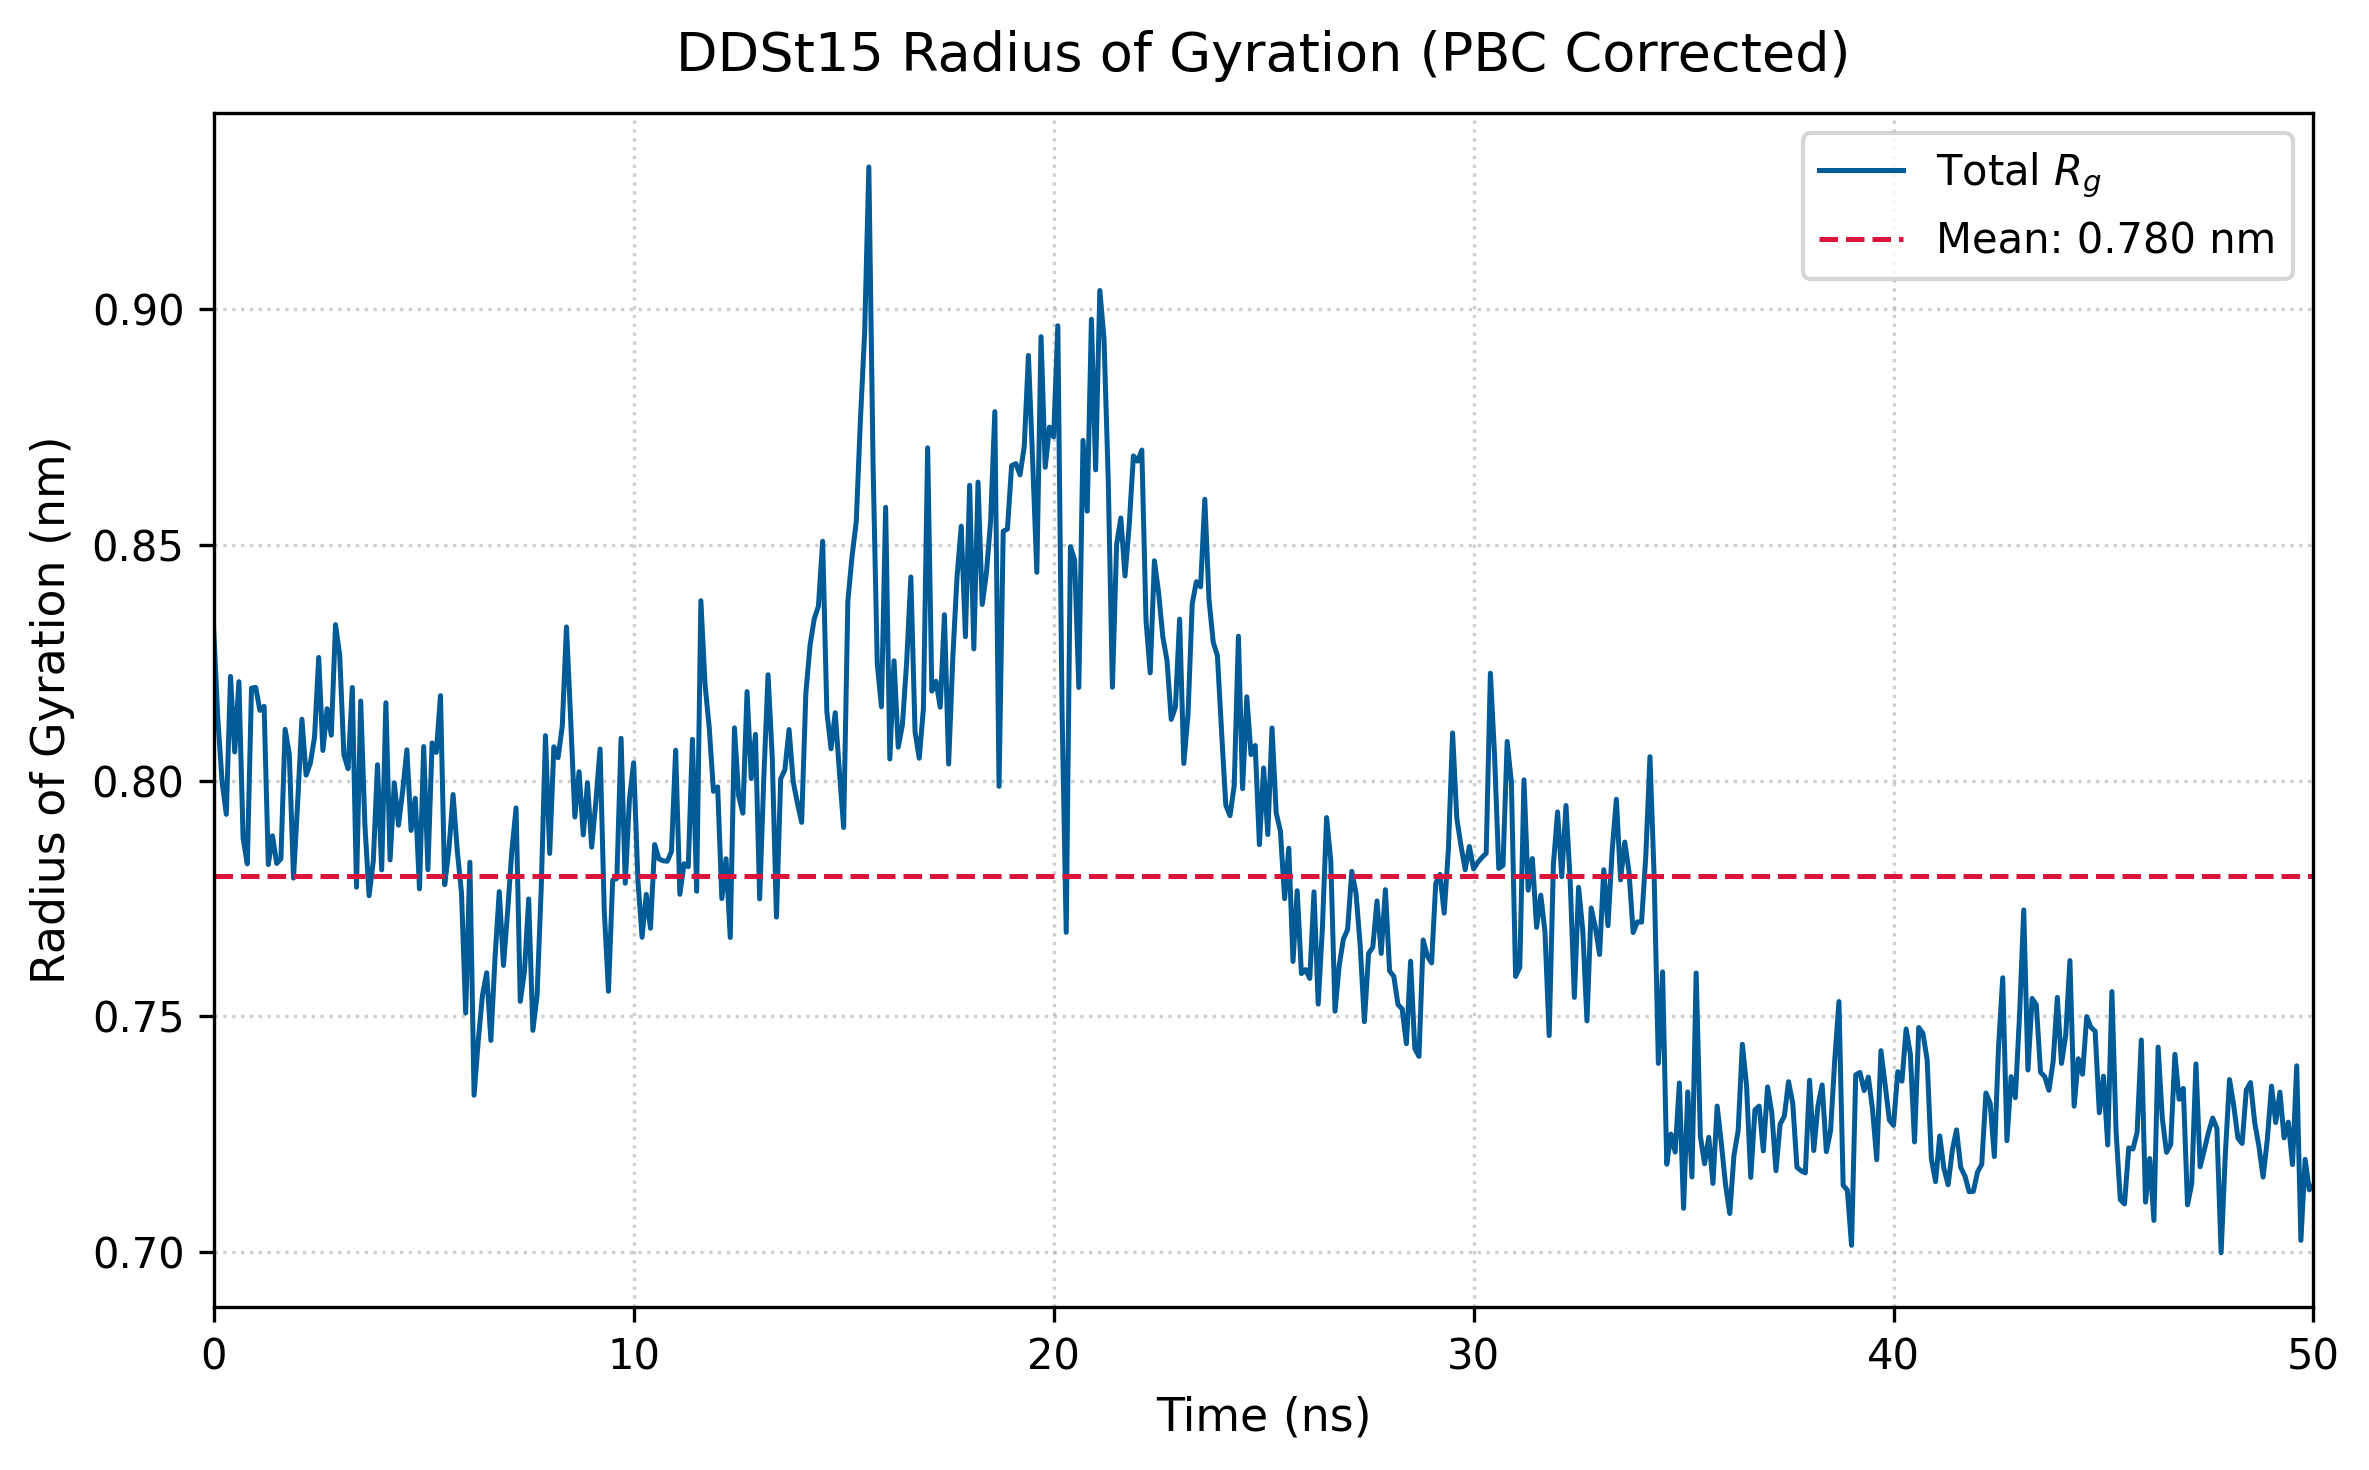


The plot was successfully saved:
D:\uni\HAP\Slab+ force field\SN\Result of DDSt15\gyrate_corrected.png


In [180]:
import os
import matplotlib.pyplot as plt
import numpy as np

# 1. Your folder path
folder_path = r"D:\uni\HAP\Slab+ force field\SN\Result of DDSt15"
xvg_file = os.path.join(folder_path, "gyrate_corrected.xvg")
output_plot = os.path.join(folder_path, "gyrate_corrected.png")

# 2. Read the xvg file (ignoring GROMACS comments)
time = []
rg = []

with open(xvg_file, "r") as f:
    for line in f:
        line = line.strip()
        if not line or line.startswith(("#", "@")):
            continue
        parts = line.split()
        time.append(float(parts[0]))
        rg.append(float(parts[1]))  # Second column: total radius of gyration

time = np.array(time)
rg = np.array(rg)

# Convert time to nanoseconds (if it is in picoseconds)
if time.max() > 1000:
    time = time / 1000.0

# 3. Statistical calculations
total_mean = np.mean(rg)
total_std = np.std(rg)
min_rg = np.min(rg)
max_rg = np.max(rg)

# First and last 10 percent
n_frames = len(rg)
idx_10 = int(0.1 * n_frames)

mean_init = np.mean(rg[:idx_10])
std_init = np.std(rg[:idx_10])

mean_final = np.mean(rg[-idx_10:])
std_final = np.std(rg[-idx_10:])

# Print results to the console
print("=" * 45)
print("       DDSt15 Radius of Gyration (Rg)")
print("=" * 45)
print(f"Total Range:        {min_rg:.3f} to {max_rg:.3f} nm")
print(f"Overall Mean ± SD:  {total_mean:.3f} ± {total_std:.3f} nm")
print(f"First 10% (0-5 ns): {mean_init:.3f} ± {std_init:.3f} nm")
print(f"Last 10% (45-50 ns):{mean_final:.3f} ± {std_final:.3f} nm")
print("=" * 45)

# 4. Plot the graph
plt.figure(figsize=(8, 5), dpi=300)
plt.plot(time, rg, color="#005b96", linewidth=1.2, label=r"Total $R_g$")

# Mean line
plt.axhline( total_mean, color="crimson", linestyle="--", linewidth=1.2, label=f"Mean: {total_mean:.3f} nm",)
plt.title("DDSt15 Radius of Gyration (PBC Corrected)", fontsize=13, pad=10)
plt.xlabel("Time (ns)", fontsize=11)
plt.ylabel("Radius of Gyration (nm)", fontsize=11)
plt.xlim(time.min(), time.max())
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(loc="upper right", frameon=True)
plt.tight_layout()

# Save the image
plt.savefig(output_plot)
plt.show()
print(f"\nThe plot was successfully saved:\n{output_plot}")

## Step 8 — Solvent Accessible Surface Area (SASA)

Calculate the solvent accessible surface area (SASA) of DDSt15 throughout the 50 ns trajectory to evaluate changes in its solvent-exposed surface.

### Tasks
- Calculate SASA for all DDSt15 atoms across the trajectory.
- Analyze SASA variation over time.
- Calculate mean, standard deviation, minimum, and maximum SASA.
- Compare the first and last 10% of the trajectory.

### Outputs
- SASA vs. time CSV
- SASA vs. time plot
- Summary statistics

DDSt15 SASA ANALYSIS — STEP 8
GROMACS XVG-based analysis

GROMACS SASA XVG: PASS

[1] Loading GROMACS SASA data...
Number of frames: 501
Time range: 0.0 - 50000.0 ps
SASA range: 16.4480 - 22.3420 nm²

[2] Calculating summary statistics...

SASA Summary:
Number_of_frames: 501
Trajectory_duration_ns: 50.000000
Mean_SASA_nm2: 18.805238
SD_SASA_nm2: 1.069714
Min_SASA_nm2: 16.448000
Max_SASA_nm2: 22.342000
First_10_percent_mean_SASA_nm2: 19.066780
First_10_percent_SD_SASA_nm2: 0.522261
Last_10_percent_mean_SASA_nm2: 17.588680
Last_10_percent_SD_SASA_nm2: 0.550403

[3] Saving results...
Saved: ddst15_sasa_gromacs.csv
Saved: sasa_gromacs_summary.csv

[4] Generating SASA plot...


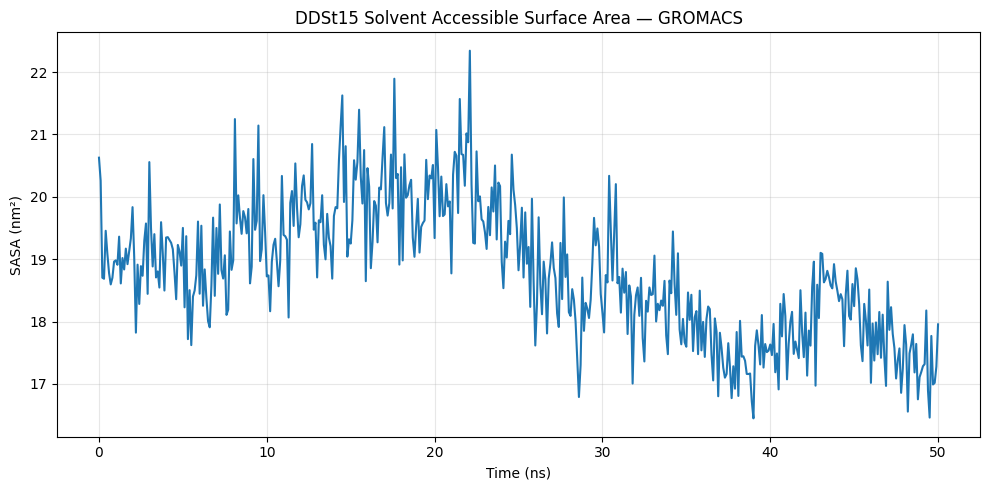

Saved: ddst15_sasa_gromacs.png
Saved: ddst15_sasa_gromacs.svg

[5] Validation
SASA finite values: PASS
Expected frame count (501): PASS

STEP 8 COMPLETED


In [160]:
# ============================================================
# DDSt15 — STEP 8: Solvent Accessible Surface Area (SASA)
# GROMACS-based analysis
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

INPUT_DIR = Path( r"D:\uni\HAP\Slab+ force field\SN\Result of DDSt15")
OUTPUT_DIR = Path( r"D:\uni\HAP\Slab+ force field\SN\analysis of DDSt15\Step_8_SASA")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
# Change this path to your actual GROMACS SASA XVG file
GROMACS_XVG = INPUT_DIR / "sasa.xvg"

# ------------------------------------------------------------
# Validate input file
# ------------------------------------------------------------

print("=" * 70)
print("DDSt15 SASA ANALYSIS — STEP 8")
print("GROMACS XVG-based analysis")
print("=" * 70)

if not GROMACS_XVG.exists():
    raise FileNotFoundError( f"GROMACS SASA file not found: {GROMACS_XVG}" )
print("\nGROMACS SASA XVG: PASS")

# ------------------------------------------------------------
# Load GROMACS XVG
# ------------------------------------------------------------

print("\n[1] Loading GROMACS SASA data...")

data = []

with open(GROMACS_XVG, "r") as f:
    for line in f:
        line = line.strip()
        # Skip GROMACS comments and metadata
        if not line or line.startswith("@") or line.startswith("#"):
            continue

        parts = line.split()

        if len(parts) < 2:
            continue

        try:
            time_ps = float(parts[0])
            sasa_nm2 = float(parts[1])
            data.append( [time_ps, sasa_nm2])

        except ValueError:
            continue


if len(data) == 0:
    raise ValueError( "No numerical SASA data were found in the XVG file." )

sasa_df = pd.DataFrame(data, columns=[  "Time_ps",   "SASA_nm2" ])
sasa_df["Time_ns"] = ( sasa_df["Time_ps"] / 1000.0)
print(f"Number of frames: {len(sasa_df)}")

print(
    f"Time range: "
    f"{sasa_df['Time_ps'].iloc[0]:.1f} - "
    f"{sasa_df['Time_ps'].iloc[-1]:.1f} ps"
)

print(
    f"SASA range: "
    f"{sasa_df['SASA_nm2'].min():.4f} - "
    f"{sasa_df['SASA_nm2'].max():.4f} nm²"
)


# ------------------------------------------------------------
# Summary statistics
# ------------------------------------------------------------

print("\n[2] Calculating summary statistics...")
sasa_values = sasa_df["SASA_nm2"].to_numpy()
n_frames = len(sasa_values)
n_10 = max( 1, int(round(0.10 * n_frames)))
first_10 = sasa_values[:n_10]
last_10 = sasa_values[-n_10:]

summary = {
    "Number_of_frames": n_frames,

    "Trajectory_duration_ns":
        (sasa_df["Time_ps"].iloc[-1]
         - sasa_df["Time_ps"].iloc[0]) / 1000.0,

    "Mean_SASA_nm2":
        np.mean(sasa_values),

    "SD_SASA_nm2":
        np.std(sasa_values, ddof=1),

    "Min_SASA_nm2":
        np.min(sasa_values),

    "Max_SASA_nm2":
        np.max(sasa_values),

    "First_10_percent_mean_SASA_nm2":
        np.mean(first_10),

    "First_10_percent_SD_SASA_nm2":
        np.std(first_10, ddof=1),

    "Last_10_percent_mean_SASA_nm2":
        np.mean(last_10),

    "Last_10_percent_SD_SASA_nm2":
        np.std(last_10, ddof=1),
}


summary_df = pd.DataFrame( list(summary.items()), columns=["Parameter",  "Value" ])

print("\nSASA Summary:")
for parameter, value in summary.items():
    if isinstance(value, (float, np.floating)):

        print(
            f"{parameter}: "
            f"{value:.6f}"
        )

    else:

        print(
            f"{parameter}: "
            f"{value}"
        )


# ------------------------------------------------------------
# Save SASA data
# ------------------------------------------------------------

print("\n[3] Saving results...")

sasa_csv = ( OUTPUT_DIR /"ddst15_sasa_gromacs.csv")
summary_csv = ( OUTPUT_DIR /"sasa_gromacs_summary.csv")
sasa_df.to_csv( sasa_csv,  index=False)
summary_df.to_csv( summary_csv,  index=False)
print(f"Saved: {sasa_csv.name}")
print(f"Saved: {summary_csv.name}")

# ------------------------------------------------------------
# Plot SASA vs time
# ------------------------------------------------------------

print("\n[4] Generating SASA plot...")
plt.figure(figsize=(10, 5))
plt.plot( sasa_df["Time_ns"], sasa_df["SASA_nm2"], linewidth=1.5)
plt.xlabel("Time (ns)")
plt.ylabel("SASA (nm²)")
plt.title("DDSt15 Solvent Accessible Surface Area — GROMACS")
plt.grid(alpha=0.3)
plt.tight_layout()
png_file = (OUTPUT_DIR /"ddst15_sasa_gromacs.png")
svg_file = ( OUTPUT_DIR /"ddst15_sasa_gromacs.svg")
plt.savefig( png_file, dpi=300)
plt.savefig(svg_file)
plt.show()
print(f"Saved: {png_file.name}")
print(f"Saved: {svg_file.name}")


# ------------------------------------------------------------
# Final validation
# ------------------------------------------------------------

print("\n[5] Validation")

if np.all(np.isfinite(sasa_values)):

    print("SASA finite values: PASS")

else:

    print("SASA finite values: FAIL")


if n_frames == 501:

    print("Expected frame count (501): PASS")

else:

    print(
        f"Frame count check: REVIEW "
        f"(found {n_frames}, expected 501)"
    )


# ------------------------------------------------------------
# Final output
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("STEP 8 COMPLETED")
print("=" * 70)

# Step 9 — Hydrogen Bond Analysis

## Objective

Analyze the hydrogen-bonding behavior of DDSt15 throughout the 50 ns MD simulation using the GROMACS hydrogen-bond analysis output.

## Tasks

- Read the GROMACS hydrogen-bond output.
- Calculate mean, SD, minimum, and maximum hydrogen bonds.
- Compare the first and last 10% of the trajectory.
- Analyze hydrogen-bond variation over time.
- Validate the trajectory data.
- Save the numerical results and time-dependent plot.

## Expected Outputs

- `ddst15_hydrogen_bonds_gromacs.csv`
- `hydrogen_bond_gromacs_summary.csv`
- `ddst15_hydrogen_bonds_gromacs.png`
- `ddst15_hydrogen_bonds_gromacs.svg`

Input file found:
D:\uni\HAP\Slab+ force field\SN\Result of DDSt15\hbnum.xvg

STEP 9 — HYDROGEN BOND ANALYSIS

Trajectory validation:
Number of frames: 501 — PASS
Time range: 0.00–50.00 ns
Finite H-bond values: True — PASS

Hydrogen-bond statistics:
Mean              : 11.385
SD                : 2.128
Minimum           : 6.000
Maximum           : 17.000
First 10%         : 11.120 ± 2.086
Last 10%          : 12.640 ± 1.925


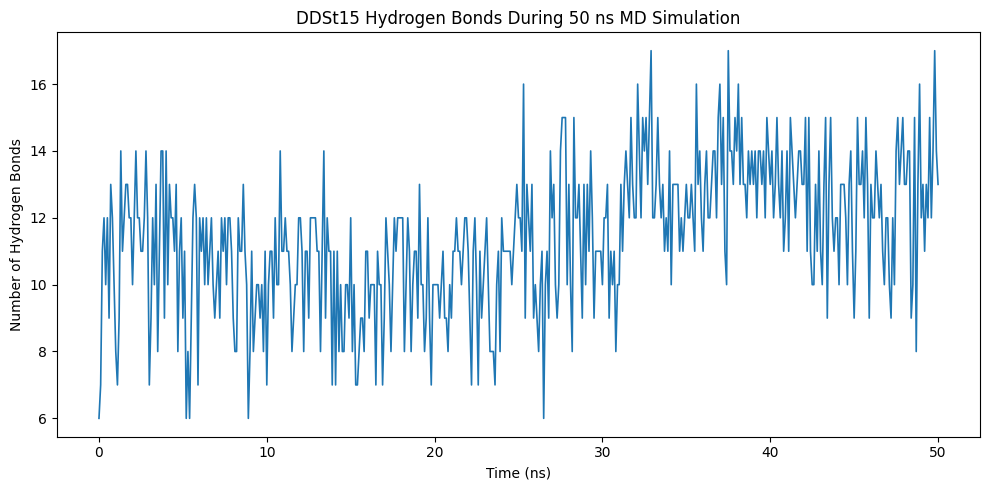


FILES SAVED
D:\uni\HAP\Slab+ force field\SN\analysis of DDSt15\Step_9_Hydrogen_Bonds\ddst15_hydrogen_bonds_gromacs.csv
D:\uni\HAP\Slab+ force field\SN\analysis of DDSt15\Step_9_Hydrogen_Bonds\hydrogen_bond_gromacs_summary.csv
D:\uni\HAP\Slab+ force field\SN\analysis of DDSt15\Step_9_Hydrogen_Bonds\ddst15_hydrogen_bonds_gromacs.png
D:\uni\HAP\Slab+ force field\SN\analysis of DDSt15\Step_9_Hydrogen_Bonds\ddst15_hydrogen_bonds_gromacs.svg

Step 9 completed successfully.


In [172]:
# ============================================================
# Step 9 — Hydrogen Bond Analysis
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

INPUT_DIR = Path(r"D:\uni\HAP\Slab+ force field\SN\Result of DDSt15")
OUTPUT_DIR = Path(r"D:\uni\HAP\Slab+ force field\SN\analysis of DDSt15\Step_9_Hydrogen_Bonds")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
HBOND_FILE = INPUT_DIR / "hbnum.xvg"

# ------------------------------------------------------------
# Check input
# ------------------------------------------------------------

if not HBOND_FILE.exists():
    raise FileNotFoundError(  f"GROMACS H-bond output not found:\n{HBOND_FILE}" )
print("Input file found:")
print(HBOND_FILE)

# ------------------------------------------------------------
# Read GROMACS XVG
# ------------------------------------------------------------

data = []
with open(HBOND_FILE, "r") as f:
    for line in f:
        line = line.strip()

        if not line:
            continue

        if line.startswith("#") or line.startswith("@"):
            continue

        values = line.split()

        if len(values) >= 2:
            try:
                time_ps = float(values[0])
                hbond_count = float(values[1])

                data.append([time_ps, hbond_count])

            except ValueError:
                continue

if not data:
    raise ValueError( "No numerical H-bond data were found in hbnum.xvg."  )

df = pd.DataFrame( data,columns=["Time_ps", "Hydrogen_Bonds"])
df["Time_ns"] = df["Time_ps"] / 1000.0

# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

expected_frames = 501
print("\n" + "=" * 70)
print("STEP 9 — HYDROGEN BOND ANALYSIS")
print("=" * 70)
print("\nTrajectory validation:")
print(
    f"Number of frames: {len(df)} — "
    f"{'PASS' if len(df) == expected_frames else 'CHECK'}"
)

print(
    f"Time range: "
    f"{df['Time_ns'].iloc[0]:.2f}–"
    f"{df['Time_ns'].iloc[-1]:.2f} ns"
)

print(
    f"Finite H-bond values: "
    f"{np.isfinite(df['Hydrogen_Bonds']).all()} — PASS"
)

# ------------------------------------------------------------
# Statistics
# ------------------------------------------------------------

hbonds = df["Hydrogen_Bonds"]

mean_hb = hbonds.mean()
std_hb = hbonds.std()
min_hb = hbonds.min()
max_hb = hbonds.max()

# First and last 10%
n10 = max(1, int(len(df) * 0.10))

first10 = hbonds.iloc[:n10]
last10 = hbonds.iloc[-n10:]

first10_mean = first10.mean()
first10_sd = first10.std()

last10_mean = last10.mean()
last10_sd = last10.std()

# ------------------------------------------------------------
# Print results
# ------------------------------------------------------------

print("\nHydrogen-bond statistics:")

print(f"Mean              : {mean_hb:.3f}")
print(f"SD                : {std_hb:.3f}")
print(f"Minimum           : {min_hb:.3f}")
print(f"Maximum           : {max_hb:.3f}")

print(
    f"First 10%         : "
    f"{first10_mean:.3f} ± {first10_sd:.3f}"
)

print(
    f"Last 10%          : "
    f"{last10_mean:.3f} ± {last10_sd:.3f}"
)

# ------------------------------------------------------------
# Summary table
# ------------------------------------------------------------

summary = pd.DataFrame({
    "Metric": [
        "Number of frames",
        "Time range (ns)",
        "Mean hydrogen bonds",
        "SD hydrogen bonds",
        "Minimum hydrogen bonds",
        "Maximum hydrogen bonds",
        "First 10% mean",
        "First 10% SD",
        "Last 10% mean",
        "Last 10% SD"
    ],
    "Value": [
        len(df),
        f"{df['Time_ns'].iloc[0]:.2f}–{df['Time_ns'].iloc[-1]:.2f}",
        mean_hb,
        std_hb,
        min_hb,
        max_hb,
        first10_mean,
        first10_sd,
        last10_mean,
        last10_sd
    ]
})

# ------------------------------------------------------------
# Save numerical results
# ------------------------------------------------------------

csv_file = OUTPUT_DIR / "ddst15_hydrogen_bonds_gromacs.csv"
summary_file = OUTPUT_DIR / "hydrogen_bond_gromacs_summary.csv"

df.to_csv(csv_file, index=False)
summary.to_csv(summary_file, index=False)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))
plt.plot(df["Time_ns"],df["Hydrogen_Bonds"],linewidth=1.2)
plt.xlabel("Time (ns)")
plt.ylabel("Number of Hydrogen Bonds")
plt.title("DDSt15 Hydrogen Bonds During 50 ns MD Simulation")
plt.tight_layout()
png_file = OUTPUT_DIR / "ddst15_hydrogen_bonds_gromacs.png"
svg_file = OUTPUT_DIR / "ddst15_hydrogen_bonds_gromacs.svg"
plt.savefig(png_file, dpi=300)
plt.savefig(svg_file)
plt.show()

# ------------------------------------------------------------
# Final status
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("FILES SAVED")
print("=" * 70)

print(csv_file)
print(summary_file)
print(png_file)
print(svg_file)

print("\nStep 9 completed successfully.")

## Step 10- Supplementary Thermodynamic Convergence

Evaluated remaining NPT parameters ($T = 310.15\text{ K}$, $P = 1.0\text{ bar}$) over 50 ns to confirm complete thermodynamic stability:

* **Kinetic Energy ($E_\text{kin}$):** Symmetric thermal fluctuations matching target temperature ($310.15\text{ K}$).
* **Total Energy ($E_\text{tot}$):** Well-conserved with zero long-term energetic drift ($\Delta E / \Delta t \approx 0$).
* **Density ($\rho$):** Stable within the physical range for physiological saline ($\sim 1000 - 1015\text{ kg/m}^3$).
* **Enthalpy ($H$):** Stable constant-pressure thermodynamic potential ($H = E_\text{tot} + PV$).

Reading file: D:\uni\HAP\Slab+ force field\SN (+solvent)\Result of DDSt15 from gromacs\energy_all.xvg
Kinetic Energy       |   28292.81 ± 285.77   |   28293.31     |   28307.89     |     0.2958
Total Energy         | -128885.05 ± 534.56   | -128858.84     | -128861.39     |     0.3141
Density              |    1014.23 ± 5.02     |    1014.15     |    1014.26     |    -0.0004
Enthalpy             | -128878.52 ± 534.57   | -128852.30     | -128854.85     |     0.3141

Summary text saved to: D:\uni\HAP\Slab+ force field\SN (+solvent)\analysis of DDSt15\Step 10- Supplementary Thermodynamic Convergence\thermodynamic_summary.txt


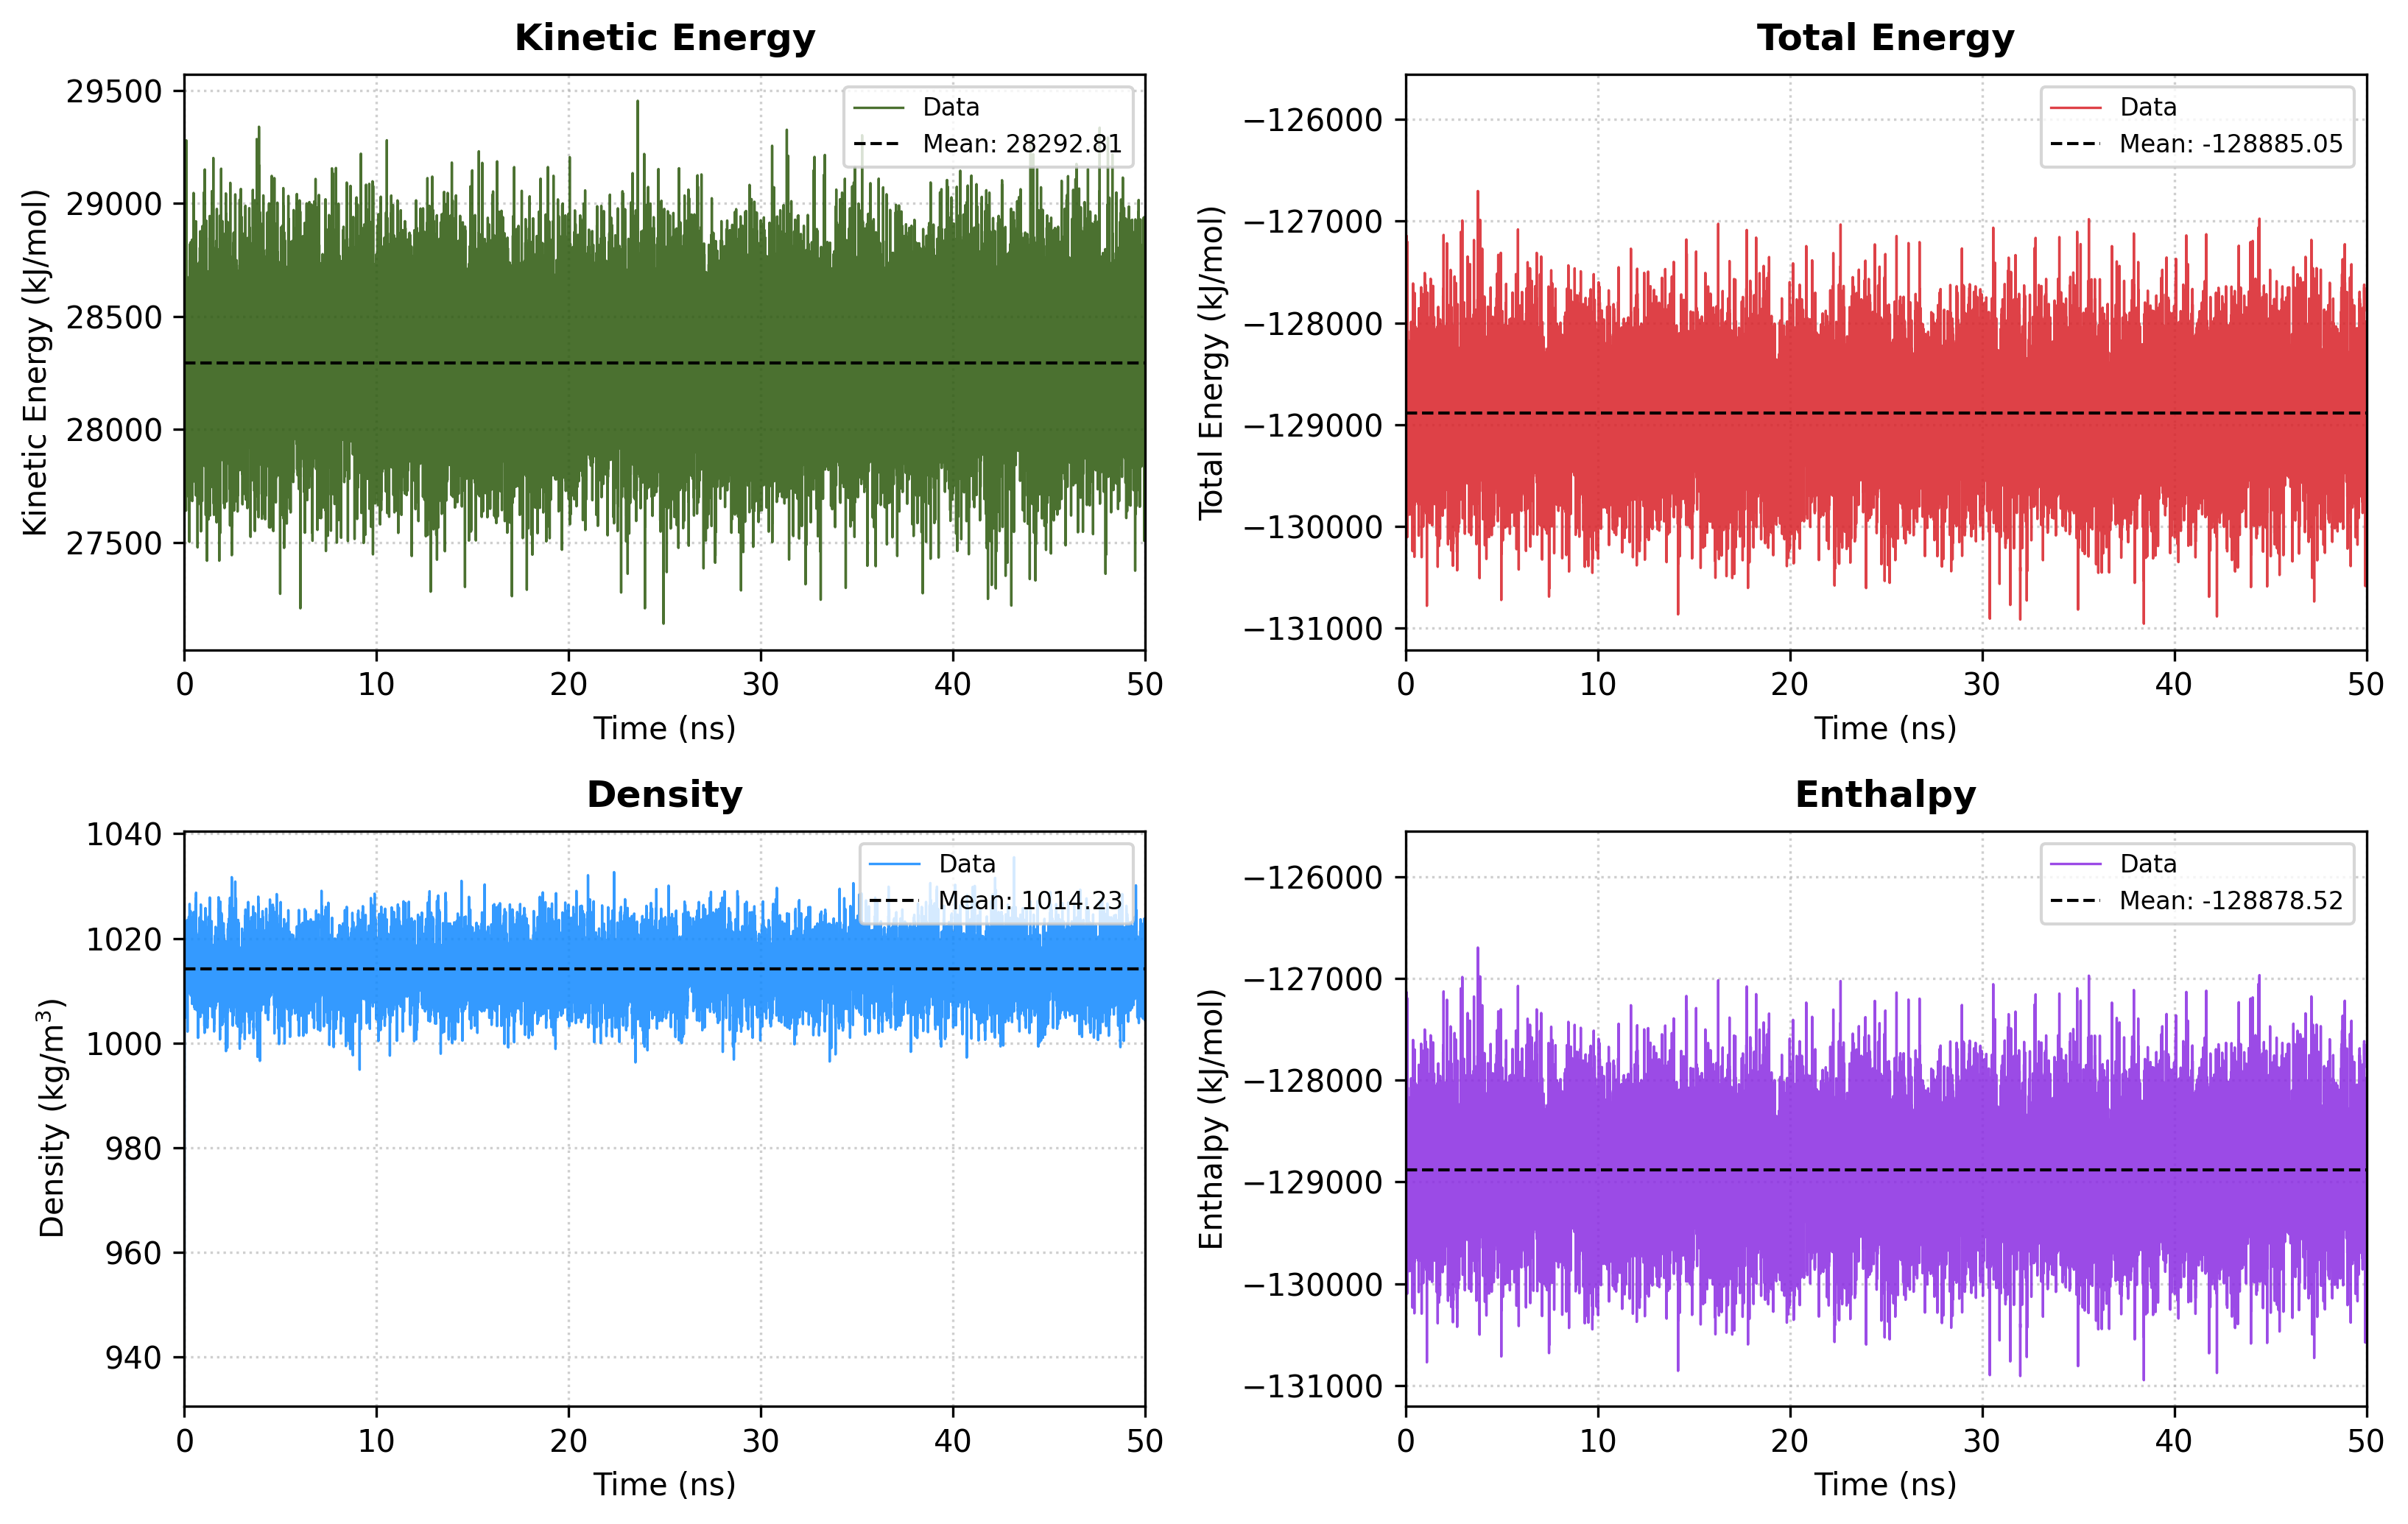

Plot saved successfully to: D:\uni\HAP\Slab+ force field\SN (+solvent)\analysis of DDSt15\Step 10- Supplementary Thermodynamic Convergence\supplementary_thermodynamics.png


In [9]:
import os
import matplotlib.pyplot as plt
import numpy as np

# 1. Define Paths
input_dir = (  r"D:\uni\HAP\Slab+ force field\SN (+solvent)\Result of DDSt15 from gromacs")
output_dir = r"D:\uni\HAP\Slab+ force field\SN (+solvent)\analysis of DDSt15\Step 10- Supplementary Thermodynamic Convergence"
os.makedirs(output_dir, exist_ok=True)
# 2. Locate Input XVG File
xvg_file = os.path.join(input_dir, "energy_all.xvg")
if not os.path.exists(xvg_file):
    # Fallback search if named differently
    for f in os.listdir(input_dir):
        if f.endswith(".xvg") and "energy" in f.lower():
            xvg_file = os.path.join(input_dir, f)
            break

print(f"Reading file: {xvg_file}")
# 3. Dynamic Header and Legend Parsing
legend_map = {}
with open(xvg_file, "r") as f:
    for line in f:
        line = line.strip()
        if line.startswith("@ s") and "legend" in line:
            # Parse format: @ s0 legend "Potential"
            parts = line.split('"')
            if len(parts) >= 2:
                series_id = int(line.split()[1].replace("s", ""))
                legend_name = parts[1].strip()
                legend_map[legend_name] = (series_id + 1)  # +1 because column 0 is Time

# Target properties
target_keys = {
    "Kinetic En.": ("Kinetic Energy", "kJ/mol", "#2b580c"),
    "Total Energy": ("Total Energy", "kJ/mol", "#d92027"),
    "Density": ("Density", r"$\mathrm{kg/m^3}$", "#1089ff"),
    "Enthalpy": ("Enthalpy", "kJ/mol", "#8a2be2"),
}

# Verify columns exist
selected_cols = {}
for legend_name, (title, unit, color) in target_keys.items():
    if legend_name in legend_map:
        selected_cols[title] = { "col_idx": legend_map[legend_name],"unit": unit,"color": color, "data": [], }
    else:
        # Partial match fallback
        matched = False
        for k in legend_map:
            if legend_name.lower() in k.lower():
                selected_cols[title] = {"col_idx": legend_map[k], "unit": unit,"color": color,"data": [],}
                matched = True
                break
        if not matched:
            print(f"Warning: Property '{legend_name}' not found in header.")

# 4. Read Data
time_list = []
with open(xvg_file, "r") as f:
    for line in f:
        line = line.strip()
        if not line or line.startswith(("#", "@")):
            continue
        parts = [float(p) for p in line.split()]
        time_list.append(parts[0])
        for prop, info in selected_cols.items():
            info["data"].append(parts[info["col_idx"]])

time = np.array(time_list)
if time.max() > 1000:
    time = time / 1000.0  # Convert ps to ns

for prop in selected_cols:
    selected_cols[prop]["data"] = np.array(selected_cols[prop]["data"])

# 5. Statistical Calculations and Console Output
n_frames = len(time)
n_10 = int(0.1 * n_frames)

summary_lines = []
summary_lines.append("=" * 70)
summary_lines.append(" STEP 10: SUPPLEMENTARY THERMODYNAMIC CONVERGENCE")
summary_lines.append("=" * 70)
summary_lines.append( f"{'Property':<20} | {'Mean ± SD':<22} | {'First 10%':<14} | {'Last 10%':<14} | {'Drift (unit/ns)':<14}")
summary_lines.append("-" * 70)

for prop, info in selected_cols.items():
    arr = info["data"]
    mean_val = np.mean(arr)
    std_val = np.std(arr)
    init_val = np.mean(arr[:n_10])
    final_val = np.mean(arr[-n_10:])

    # Linear drift slope
    slope, _ = np.polyfit(time, arr, 1)

    line_str = f"{prop:<20} | {mean_val:10.2f} ± {std_val:<8.2f} | {init_val:10.2f}     | {final_val:10.2f}     | {slope:10.4f}"
    summary_lines.append(line_str)
    print(line_str)

summary_lines.append("=" * 70)

# Save text summary
summary_file = os.path.join(output_dir, "thermodynamic_summary.txt")
with open(summary_file, "w") as f:
    f.write("\n".join(summary_lines))

print(f"\nSummary text saved to: {summary_file}")

# 6. Generate 2x2 Publication-Quality Plot
fig, axes = plt.subplots(2, 2, figsize=(11, 7), dpi=300)
axes_flat = axes.flatten()

for idx, (prop, info) in enumerate(selected_cols.items()):
    ax = axes_flat[idx]
    arr = info["data"]
    mean_val = np.mean(arr)

    ax.plot(time, arr, color=info["color"], linewidth=0.8, alpha=0.85, label="Data")
    ax.axhline( mean_val,color="black",linestyle="--",linewidth=1.0,label=f"Mean: {mean_val:.2f}",)
    ax.set_title(prop, fontsize=12, fontweight="bold", pad=8)
    ax.set_xlabel("Time (ns)", fontsize=10)
    ax.set_ylabel(f"{prop} ({info['unit']})", fontsize=10)
    ax.set_xlim(time.min(), time.max())
    ax.grid(True, linestyle=":", alpha=0.6)
    ax.legend(loc="upper right", frameon=True, fontsize=8)

plt.tight_layout()
output_plot = os.path.join(output_dir, "supplementary_thermodynamics.png")
plt.savefig(output_plot)
plt.show()

print(f"Plot saved successfully to: {output_plot}")

### Replotting Selected Diagrams for Consistent and Improved Visualization

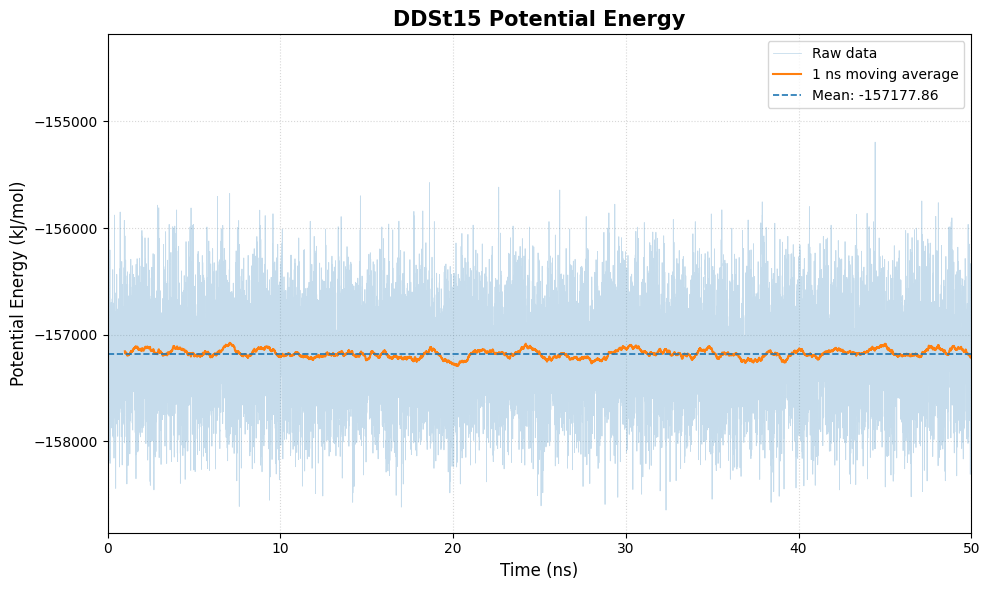

Saved: D:\uni\HAP\Slab+ force field\SN (+solvent)\analysis of DDSt15\DDSt15_Potential_Energy_final.png


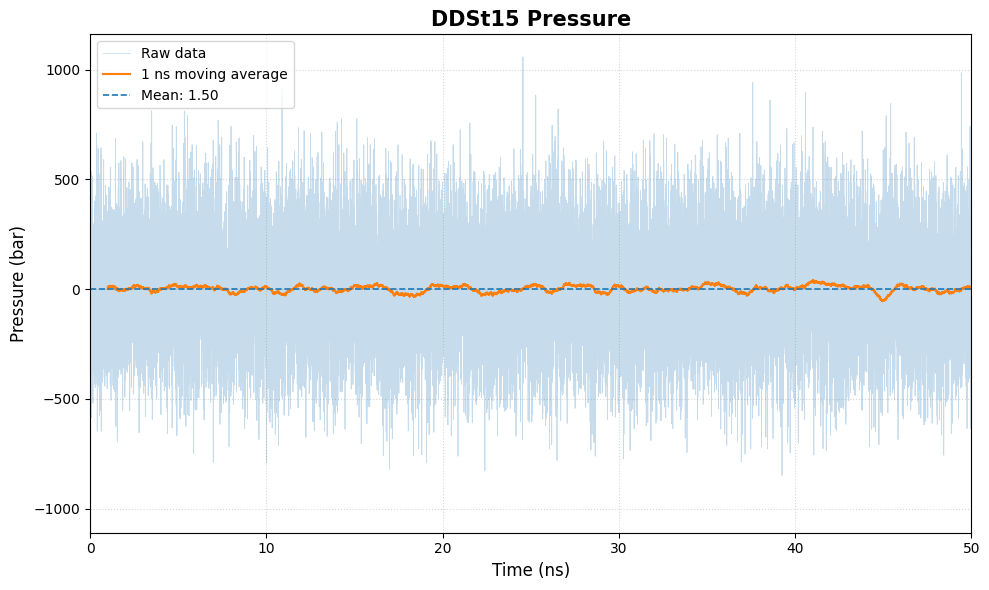

Saved: D:\uni\HAP\Slab+ force field\SN (+solvent)\analysis of DDSt15\DDSt15_Pressure_final.png


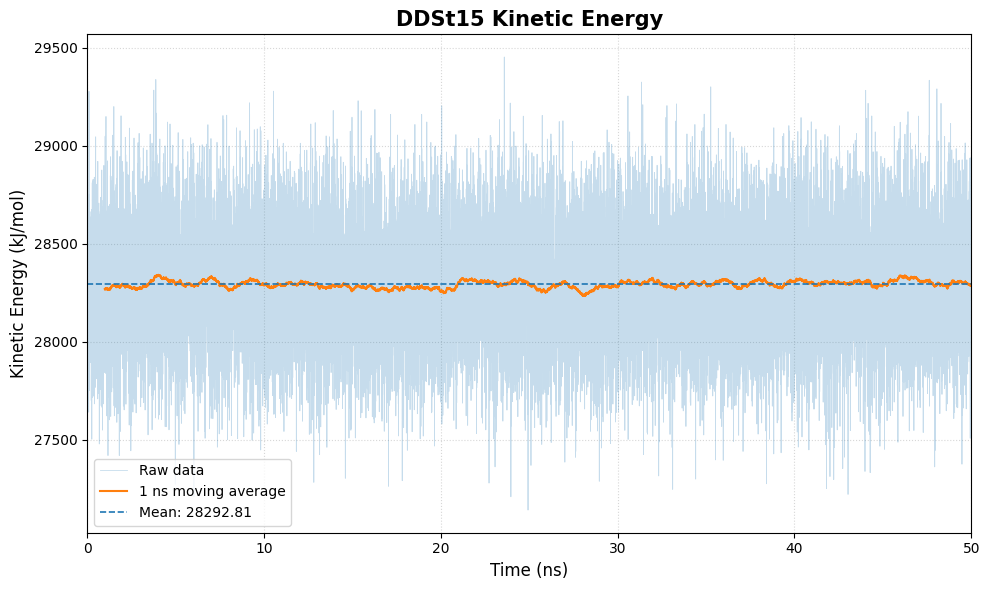

Saved: D:\uni\HAP\Slab+ force field\SN (+solvent)\analysis of DDSt15\DDSt15_Kinetic_Energy_final.png


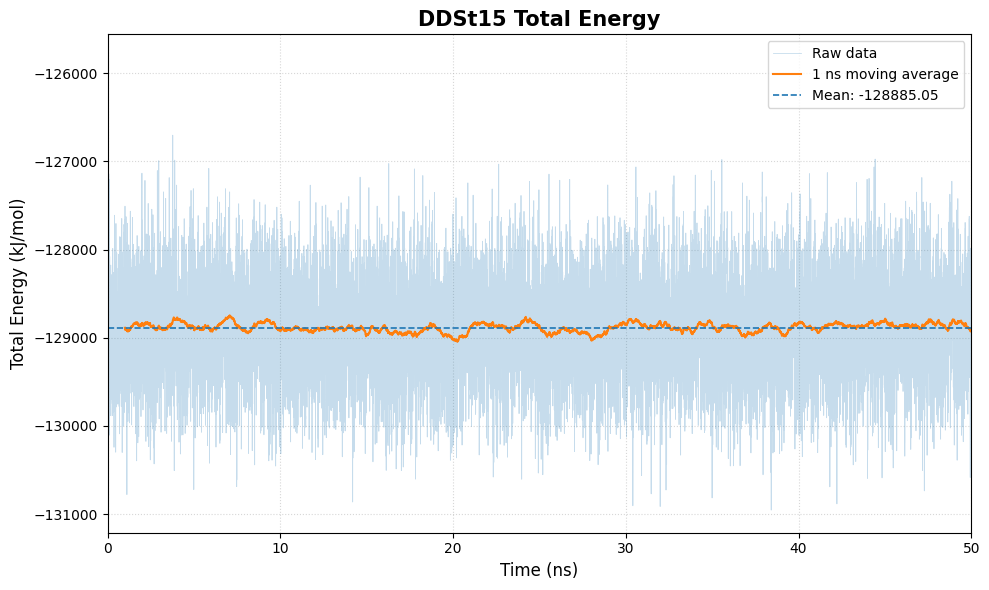

Saved: D:\uni\HAP\Slab+ force field\SN (+solvent)\analysis of DDSt15\DDSt15_Total_Energy_final.png


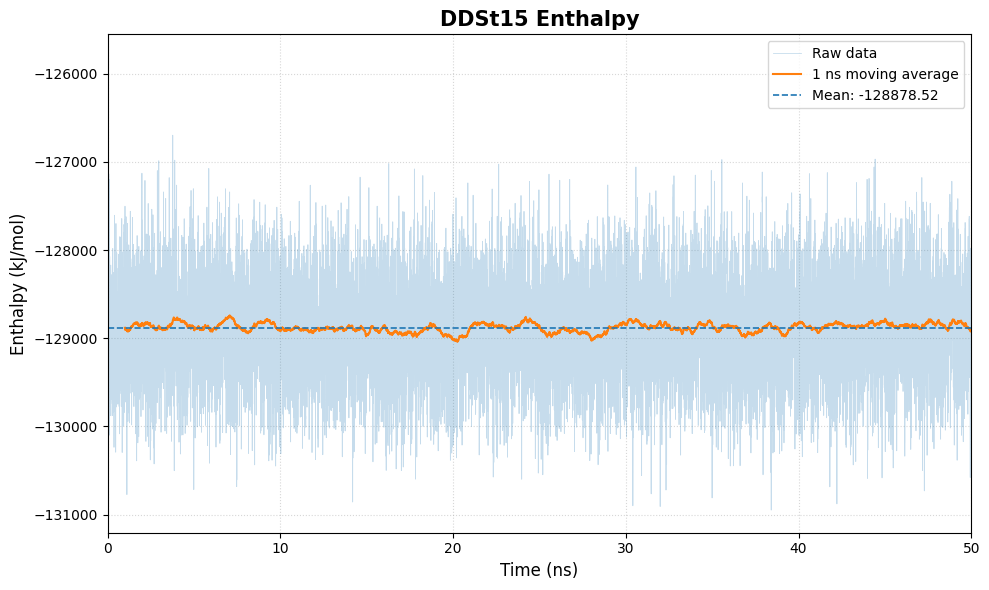

Saved: D:\uni\HAP\Slab+ force field\SN (+solvent)\analysis of DDSt15\DDSt15_Enthalpy_final.png

All five final figures have been saved successfully.


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Paths
# ============================================================

input_dir = r"D:\uni\HAP\Slab+ force field\SN (+solvent)\Result of DDSt15 from gromacs"
output_dir = r"D:\uni\HAP\Slab+ force field\SN (+solvent)\analysis of DDSt15"

os.makedirs(output_dir, exist_ok=True)


# ============================================================
# XVG reader
# ============================================================

def read_xvg(filename, column=1):
    """
    Read time and data from a GROMACS XVG file.
    Lines beginning with # or @ are ignored.
    """

    time = []
    values = []

    with open(filename, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            line = line.strip()

            if not line or line.startswith("#") or line.startswith("@"):
                continue

            parts = line.split()

            if len(parts) > column:
                time.append(float(parts[0]))
                values.append(float(parts[column]))

    return np.array(time), np.array(values)


# ============================================================
# Moving average
# ============================================================

def moving_average(time, values, window_ns=1.0):
    """
    Calculate a moving average using a time window in ns.
    """

    if len(time) < 2:
        return time, values

    dt = np.median(np.diff(time))
    window_points = max(1, int(round(window_ns / dt)))
    kernel = np.ones(window_points) / window_points
    smoothed = np.convolve(values, kernel, mode="valid")
    time_smoothed = time[window_points - 1:]
    return time_smoothed, smoothed


# ============================================================
# Plot function
# ============================================================

def plot_energy( time,values,title, ylabel, output_filename, show_moving_average=True,mean_line=True):
    # Convert ps to ns
    time_ns = time / 1000.0
    mean_value = np.mean(values)
    plt.figure(figsize=(10, 6))
    # Raw trajectory
    plt.plot(time_ns,values,linewidth=0.6,alpha=0.25,label="Raw data")
    # Moving average
    if show_moving_average:
        smooth_time, smooth_values = moving_average( time_ns,values,window_ns=1.0)
        plt.plot( smooth_time,smooth_values,linewidth=1.5,label="1 ns moving average" )

    # Mean line
    if mean_line:
        plt.axhline(mean_value, linestyle="--",linewidth=1.2, label=f"Mean: {mean_value:.2f}")

    plt.xlabel("Time (ns)", fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.title(title, fontsize=15, fontweight="bold")
    plt.xlim(0, 50)
    plt.grid(True,linestyle=":",alpha=0.5 )
    plt.legend()
    plt.tight_layout()
    output_path = os.path.join(output_dir,output_filename )
    plt.savefig( output_path, dpi=300,bbox_inches="tight")
    plt.show()
    print(f"Saved: {output_path}")


# ============================================================
# Read energy_all.xvg
# ============================================================

energy_file = os.path.join( input_dir,"energy_all.xvg")

# According to the XVG legends:
# s0 = Potential
# s1 = Kinetic Energy
# s2 = Total Energy
# s3 = Temperature
# s4 = Pressure
# s5 = Volume
# s6 = Density
# s7 = Enthalpy

energy_time = []
energy_data = []

with open(energy_file, "r", encoding="utf-8", errors="ignore") as f:

    for line in f:
        line = line.strip()

        if not line or line.startswith("#") or line.startswith("@"):
            continue

        parts = line.split()

        if len(parts) >= 9:
            energy_time.append(float(parts[0]))
            energy_data.append([float(x) for x in parts[1:9]])

energy_time = np.array(energy_time)
energy_data = np.array(energy_data)


# ============================================================
# Extract energy_all series
# ============================================================

potential_energy = energy_data[:, 0]
kinetic_energy = energy_data[:, 1]
total_energy = energy_data[:, 2]
pressure = energy_data[:, 4]
enthalpy = energy_data[:, 7]


# ============================================================
# 1. Potential Energy
# ============================================================

plot_energy(
    energy_time,
    potential_energy,
    title="DDSt15 Potential Energy",
    ylabel="Potential Energy (kJ/mol)",
    output_filename="DDSt15_Potential_Energy_final.png",
    show_moving_average=True
)


# ============================================================
# 2. Pressure
# ============================================================

plot_energy(
    energy_time,
    pressure,
    title="DDSt15 Pressure",
    ylabel="Pressure (bar)",
    output_filename="DDSt15_Pressure_final.png",
    show_moving_average=True
)


# ============================================================
# 3. Kinetic Energy
# ============================================================

plot_energy(
    energy_time,
    kinetic_energy,
    title="DDSt15 Kinetic Energy",
    ylabel="Kinetic Energy (kJ/mol)",
    output_filename="DDSt15_Kinetic_Energy_final.png",
    show_moving_average=True
)


# ============================================================
# 4. Total Energy
# ============================================================

plot_energy(
    energy_time,
    total_energy,
    title="DDSt15 Total Energy",
    ylabel="Total Energy (kJ/mol)",
    output_filename="DDSt15_Total_Energy_final.png",
    show_moving_average=True
)


# ============================================================
# 5. Enthalpy
# ============================================================

plot_energy(
    energy_time,
    enthalpy,
    title="DDSt15 Enthalpy",
    ylabel="Enthalpy (kJ/mol)",
    output_filename="DDSt15_Enthalpy_final.png",
    show_moving_average=True
)


print("\nAll five final figures have been saved successfully.")